# Deep04. 행동 스티커 만들기 — StackedHourglass vs SimpleBaseline

MPII Human Pose Dataset으로 모델을 학습하고, **StackedHourglass Network** 와 **SimpleBaseline** 두 모델을 동일 조건에서 비교한다.

## 루브릭

| 평가문항 | 상세기준 |
|---|---|
| 1. tfrecord 를 활용한 데이터셋 구성과 전처리를 통해 프로젝트 베이스라인 구성을 확인하였다. | MPII 데이터셋을 기반으로 1 epoch 에 30분 이내에 학습 가능한 베이스라인을 구축하였다. |
| 2. simplebaseline 모델을 정상적으로 구현하였다. | simplebaseline 모델을 구현하여 실습코드의 모델을 대체하여 정상적으로 학습이 진행되었다. |
| 3. Hourglass 모델과 simplebaseline 모델을 비교분석한 결과를 체계적으로 정리하였다. | 두 모델의 pose estimation 테스트결과 이미지 및 학습진행상황 등을 체계적으로 비교분석하였다. |

## 진행 순서

 1. 라이브러리 · 환경 · 상수 · 시드
 2. 데이터 EDA
 3. 전처리 함수 (parse/ptrecord/Preprocessor)
 4. 데이터셋 · DataLoader 구축
 5. StackedHourglass Network 구현 + shape 검증
 6. SimpleBaseline 구현 + shape 검증
 7. 학습 엔진(Trainer) 및 train()
 8. 학습 ① Hourglass  /  학습 ② SimpleBaseline
 9. 평가 (heatmap→keypoint, 시각화, PCK)
10. 비교 분석
11. 회고

## 실행 플로우

```
[ 데이터 ]
  train.json / validation.json (22,246 / 2,958)
  images/ (24,984장)
        |
        v
  parse_one_annotation  ──> ptrecord 샤딩 (ray, 64+8 shard, 11.7GB, 생성·검증 전용)
        | 
        v
  Preprocessor
    ROI crop (margin 0.1~0.3) -> 256x256 -> [-1,1] -> gaussian heatmap 64x64x16
        |
        v
  MPIIDataset -> DataLoader (num_workers=0, batch 16)
        |
        +---------------------------+
        v                           v
  StackedHourglass            SimpleBaseline
  (4-stage, 16.3M)            (ResNet50+deconv, 34.0M)
        |                           |
        +------------+--------------+
                     v
              Trainer (weighted MSE, Adam 7e-4, warmup 500, bf16 AMP)
                     |  epoch 별 loss/시간/VRAM -> history JSON
                     v
              체크포인트 (val loss 최저 시점)
                     |
                     v
  heatmaps_to_keypoints (argmax + 0.25칸 서브픽셀 보정)
                     |
        +------------+------------+
        v                         v
  정성 평가                   정량 평가
  (GT/HG/SB 3열 비교)        (PCKh@0.5, PCK@0.2, 관절별)
```

---
# 1. 라이브러리

In [1]:
import io
import json
import math
import os
import random

import numpy as np
import torch          # ray 보다 반드시 먼저 import
import torchvision
import PIL
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import ray

print('[ 라이브러리 버전 ]')
print(f'torch       : {torch.__version__}')
print(f'torchvision : {torchvision.__version__}')
print(f'numpy       : {np.__version__}')
print(f'Pillow      : {PIL.__version__}')
print(f'matplotlib  : {matplotlib.__version__}')
print(f'ray         : {ray.__version__}')

print()
print('[ 실행 환경 ]')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'DEVICE: {DEVICE}')

[ 라이브러리 버전 ]
torch       : 2.11.0+cu128
torchvision : 0.26.0+cu128
numpy       : 2.5.2
Pillow      : 12.2.0
matplotlib  : 3.11.1
ray         : 2.58.0

[ 실행 환경 ]
DEVICE: cuda


### 경로 · 상수 · 시드

In [32]:
# ---- 경로 ----
PROJECT_PATH = '.'
DATA_PATH = os.path.join(PROJECT_PATH, 'data')
IMAGE_PATH = os.path.join(DATA_PATH, 'images')
MODEL_PATH = os.path.join(DATA_PATH, 'models')
PT_RECORD_PATH = os.path.join(DATA_PATH, 'ptrecords_mpii')
ANNO_PATH = os.path.join(DATA_PATH, 'mpii_human_pose_v1_u12_2')
TRAIN_JSON = os.path.join(ANNO_PATH, 'train.json')
VALID_JSON = os.path.join(ANNO_PATH, 'validation.json')

# ---- 데이터/모델 공통 상수 ----
IMAGE_SHAPE = (256, 256, 3)   # 모델 입력
HEATMAP_SIZE = (64, 64)       # 모델 출력 heatmap 해상도
NUM_JOINTS = 16               # MPII keypoint 개수
NUM_HEATMAP = NUM_JOINTS
SEED = 42

# ---- 학습 하이퍼파라미터 ----
EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 7e-4


def set_seed(seed=SEED):
    """python / numpy / torch 난수를 한 번에 고정한다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

# 그래프의 한글 라벨이 깨지지 않도록 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### MPII keypoint 상수

16개 keypoint 의 인덱스와 이름, 그리고 skeleton 을 그릴 때 이을 관절 쌍(`MPII_BONES`)을 정의한다.
`scale` 은 200px 기준으로 정규화된 값이라 **200을 곱해야** 실제 몸 높이(px)가 된다.

In [3]:
R_ANKLE, R_KNEE, R_HIP = 0, 1, 2
L_HIP, L_KNEE, L_ANKLE = 3, 4, 5
PELVIS, THORAX, UPPER_NECK, HEAD_TOP = 6, 7, 8, 9
R_WRIST, R_ELBOW, R_SHOULDER = 10, 11, 12
L_SHOULDER, L_ELBOW, L_WRIST = 13, 14, 15

JOINT_NAMES = [
    'r_ankle', 'r_knee', 'r_hip', 'l_hip', 'l_knee', 'l_ankle',
    'pelvis', 'thorax', 'upper_neck', 'head_top',
    'r_wrist', 'r_elbow', 'r_shoulder', 'l_shoulder', 'l_elbow', 'l_wrist',
]

JOINT_NAMES_KO = [
    '오른발목', '오른무릎', '오른엉덩이', '왼엉덩이', '왼무릎', '왼발목',
    '골반', '흉부', '목', '머리끝',
    '오른손목', '오른팔꿈치', '오른어깨', '왼어깨', '왼팔꿈치', '왼손목',
]

# 시각화용 skeleton 연결 정의
MPII_BONES = [
    [R_ANKLE, R_KNEE], [R_KNEE, R_HIP], [R_HIP, PELVIS],
    [L_HIP, PELVIS], [L_HIP, L_KNEE], [L_KNEE, L_ANKLE],
    [PELVIS, THORAX], [THORAX, UPPER_NECK], [UPPER_NECK, HEAD_TOP],
    [THORAX, R_SHOULDER], [R_SHOULDER, R_ELBOW], [R_ELBOW, R_WRIST],
    [THORAX, L_SHOULDER], [L_SHOULDER, L_ELBOW], [L_ELBOW, L_WRIST],
]

# MPII 의 scale 은 200px 기준 정규화 값이므로 200 을 곱해야 실제 몸 높이(px)가 된다.
SCALE_TO_PIXEL = 200.0

print(f'keypoint {NUM_JOINTS}개 / bone {len(MPII_BONES)}개')
print(' / '.join(f'{i}:{name}' for i, name in enumerate(JOINT_NAMES_KO)))

keypoint 16개 / bone 15개
0:오른발목 / 1:오른무릎 / 2:오른엉덩이 / 3:왼엉덩이 / 4:왼무릎 / 5:왼발목 / 6:골반 / 7:흉부 / 8:목 / 9:머리끝 / 10:오른손목 / 11:오른팔꿈치 / 12:오른어깨 / 13:왼어깨 / 14:왼팔꿈치 / 15:왼손목


---
# 2. 데이터 EDA

In [4]:
with open(TRAIN_JSON, encoding='utf-8') as f:
    train_raw = json.load(f)
with open(VALID_JSON, encoding='utf-8') as f:
    valid_raw = json.load(f)

train_images = {anno['image'] for anno in train_raw}
valid_images = {anno['image'] for anno in valid_raw}

print(f'train annotation 수 : {len(train_raw):,}')
print(f'valid annotation 수 : {len(valid_raw):,}')
print(f'train 고유 이미지 수 : {len(train_images):,}')
print(f'valid 고유 이미지 수 : {len(valid_images):,}')
print(f'train/valid 이미지 중복 : {len(train_images & valid_images):,} 장')
print(f'디스크상의 이미지 파일 수 : {len(os.listdir(IMAGE_PATH)):,}')
print()
print('[ annotation 1건 예시 ]')
print(json.dumps(train_raw[0], indent=2)[:900])

train annotation 수 : 22,246
valid annotation 수 : 2,958
train 고유 이미지 수 : 14,679
valid 고유 이미지 수 : 2,729
train/valid 이미지 중복 : 0 장
디스크상의 이미지 파일 수 : 24,984

[ annotation 1건 예시 ]
{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "c

### annotation 필드의 의미

- **`joints`** : 16개 keypoint 의 (x, y) 픽셀 좌표. 학습의 label 이 된다.
- **`joints_vis`** : 각 keypoint 가 실제로 보이는지 여부. MPII 는 1(visible) / 0(non) 두 값뿐이다.
  (COCO 는 2/1/0 으로 occlusion 까지 구분한다.) 보이지 않는 관절은 heatmap 을 만들지 않는다.
- **`center`** : 사람 몸의 중심 좌표.
- **`scale`** : 사람 몸의 크기 비율. **200을 곱해야** 실제 몸 높이(px)가 된다.
  이미지 크기에 따라 달라지는 좌표를 보정하기 위한 값이며, crop 영역의 margin 을 정할 때 사용한다.

### keypoint 인덱스

| idx | 부위 | idx | 부위 | idx | 부위 | idx | 부위 |
|---|---|---|---|---|---|---|---|
| 0 | 오른쪽 발목 | 4 | 왼쪽 무릎 | 8 | 목 | 12 | 오른쪽 어깨 |
| 1 | 오른쪽 무릎 | 5 | 왼쪽 발목 | 9 | 머리 위 | 13 | 왼쪽 어깨 |
| 2 | 오른쪽 엉덩이 | 6 | 골반 | 10 | 오른쪽 손목 | 14 | 왼쪽 팔꿈치 |
| 3 | 왼쪽 엉덩이 | 7 | 가슴(흉부) | 11 | 오른쪽 팔꿈치 | 15 | 왼쪽 손목 |

### 2-1. 관절별 가시성 분포

어떤 관절이 자주 가려지는지 확인하여 **어떤 관절의 성능이 낮을지**를 미리 예상한다.

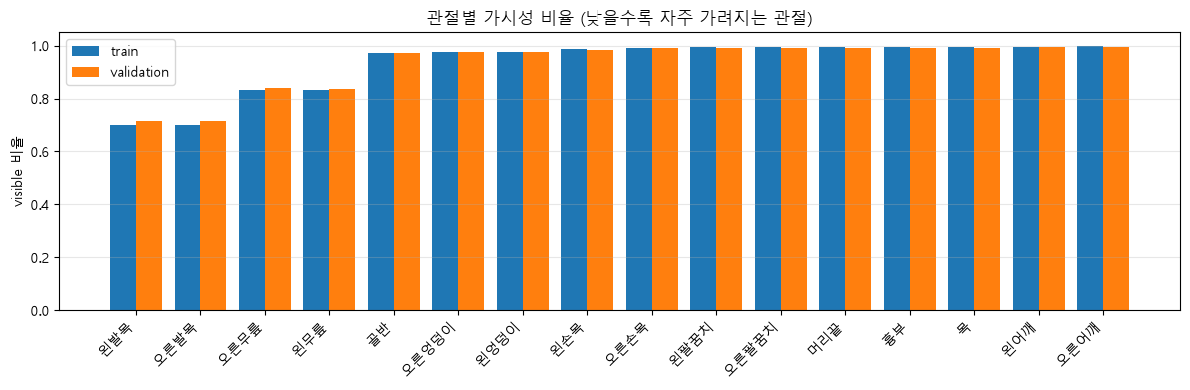

[ 가시성 낮은 관절 TOP 5 ]
  왼발목     (l_ankle    ) : 0.701
  오른발목    (r_ankle    ) : 0.702
  오른무릎    (r_knee     ) : 0.830
  왼무릎     (l_knee     ) : 0.831
  골반      (pelvis     ) : 0.972

annotation 당 평균 visible 관절 수 : 14.93 / 16
16개 전부 visible 인 annotation 비율 : 0.673
visible 관절이 2개 이하인 annotation : 1 건


In [5]:
train_vis = np.array([anno['joints_vis'] for anno in train_raw], dtype=np.float32)
valid_vis = np.array([anno['joints_vis'] for anno in valid_raw], dtype=np.float32)

train_ratio = train_vis.mean(axis=0)
valid_ratio = valid_vis.mean(axis=0)

order = np.argsort(train_ratio)
x = np.arange(NUM_JOINTS)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - 0.2, train_ratio[order], width=0.4, label='train')
ax.bar(x + 0.2, valid_ratio[order], width=0.4, label='validation')
ax.set_xticks(x)
ax.set_xticklabels([JOINT_NAMES_KO[i] for i in order], rotation=45, ha='right')
ax.set_ylabel('visible 비율')
ax.set_title('관절별 가시성 비율 (낮을수록 자주 가려지는 관절)')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('[ 가시성 낮은 관절 TOP 5 ]')
for i in order[:5]:
    print(f'  {JOINT_NAMES_KO[i]:8s}({JOINT_NAMES[i]:11s}) : {train_ratio[i]:.3f}')

print()
print(f'annotation 당 평균 visible 관절 수 : {train_vis.sum(axis=1).mean():.2f} / 16')
print(f'16개 전부 visible 인 annotation 비율 : {(train_vis.sum(axis=1) == 16).mean():.3f}')
print(f'visible 관절이 2개 이하인 annotation : {(train_vis.sum(axis=1) <= 2).sum():,} 건')

### 2-2. 사람 크기(scale) 분포

`scale × 200 = 몸 높이(px)` 이다. 이 값이 전처리에서 crop margin 의 기준이 되므로 분포를 확인한다.

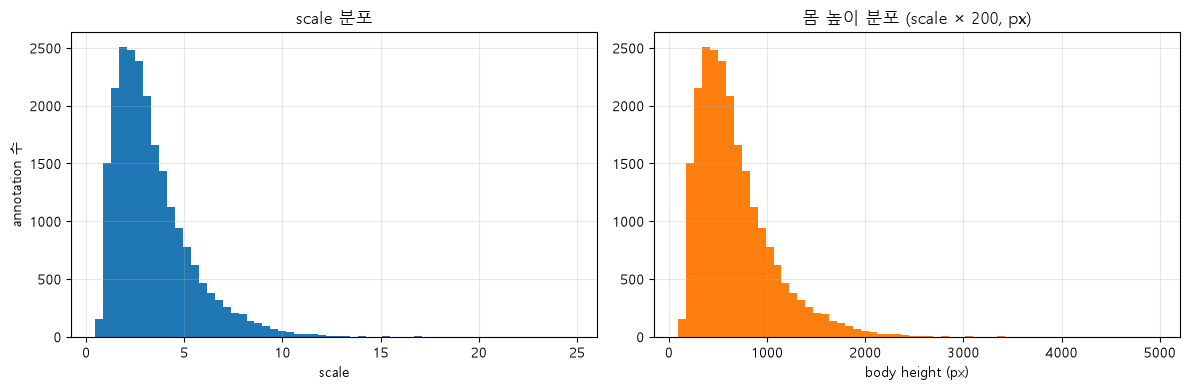

scale       : min 0.46 / median 2.89 / mean 3.35 / max 24.81
body height : min 92px / median 578px / max 4963px

→ margin=0.2 일 때 crop box 에 추가되는 여백 (중앙값 기준) : 116px


In [6]:
train_scale = np.array([anno['scale'] for anno in train_raw], dtype=np.float32)
body_height = train_scale * SCALE_TO_PIXEL

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_scale, bins=60)
axes[0].set_title('scale 분포')
axes[0].set_xlabel('scale')
axes[0].set_ylabel('annotation 수')
axes[0].grid(alpha=0.3)

axes[1].hist(body_height, bins=60, color='tab:orange')
axes[1].set_title('몸 높이 분포 (scale × 200, px)')
axes[1].set_xlabel('body height (px)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'scale       : min {train_scale.min():.2f} / median {np.median(train_scale):.2f} '
      f'/ mean {train_scale.mean():.2f} / max {train_scale.max():.2f}')
print(f'body height : min {body_height.min():.0f}px / median {np.median(body_height):.0f}px '
      f'/ max {body_height.max():.0f}px')
print()
print('→ margin=0.2 일 때 crop box 에 추가되는 여백 (중앙값 기준) : '
      f'{np.median(body_height) * 0.2:.0f}px')

### 2-3. 이미지 해상도 · 인물 중심 위치

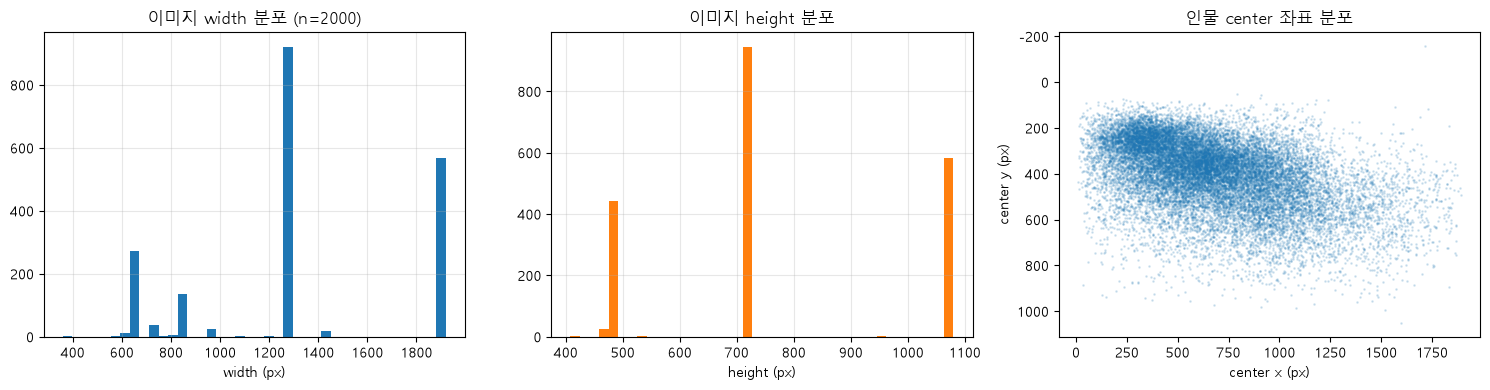

[ 최빈 해상도 TOP 5 ]
  1280 x  720 :  909 장 (45.5%)
  1920 x 1080 :  561 장 (28.1%)
   640 x  480 :  237 장 (11.8%)
   854 x  480 :   92 장 (4.6%)
   720 x  480 :   37 장 (1.8%)


In [7]:
rng = random.Random(SEED)
sample_files = rng.sample(sorted(train_images), k=min(2000, len(train_images)))

sizes = []
for fname in sample_files:
    with Image.open(os.path.join(IMAGE_PATH, fname)) as im:
        sizes.append(im.size)   # (width, height) — 헤더만 읽으므로 빠르다
sizes = np.array(sizes)

centers = np.array([anno['center'] for anno in train_raw], dtype=np.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(sizes[:, 0], bins=40)
axes[0].set_title(f'이미지 width 분포 (n={len(sizes)})')
axes[0].set_xlabel('width (px)')
axes[0].grid(alpha=0.3)

axes[1].hist(sizes[:, 1], bins=40, color='tab:orange')
axes[1].set_title('이미지 height 분포')
axes[1].set_xlabel('height (px)')
axes[1].grid(alpha=0.3)

axes[2].scatter(centers[:, 0], centers[:, 1], s=1, alpha=0.15)
axes[2].set_title('인물 center 좌표 분포')
axes[2].set_xlabel('center x (px)')
axes[2].set_ylabel('center y (px)')
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()

uniq, counts = np.unique(sizes, axis=0, return_counts=True)
top = np.argsort(-counts)[:5]
print('[ 최빈 해상도 TOP 5 ]')
for i in top:
    print(f'  {uniq[i][0]:4d} x {uniq[i][1]:4d} : {counts[i]:4d} 장 ({counts[i] / len(sizes):.1%})')

### 2-4. 이미지 한 장에 들어있는 인물 수

MPII 는 한 이미지에 여러 사람이 등장하면 **사람 수만큼 annotation** 이 생긴다.

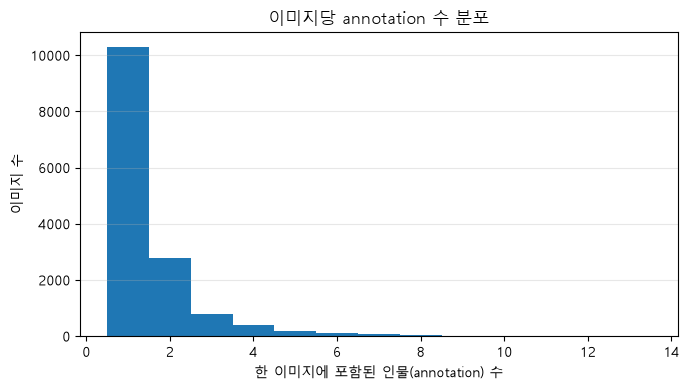

이미지당 평균 annotation : 1.52 명
2명 이상 등장하는 이미지 : 4,381 장 (29.8%)
최대 인물 수 : 13 명


In [8]:
from collections import Counter

per_image = Counter(anno['image'] for anno in train_raw)
counts = np.array(list(per_image.values()))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(counts, bins=np.arange(0.5, counts.max() + 1.5, 1))
ax.set_xlabel('한 이미지에 포함된 인물(annotation) 수')
ax.set_ylabel('이미지 수')
ax.set_title('이미지당 annotation 수 분포')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'이미지당 평균 annotation : {counts.mean():.2f} 명')
print(f'2명 이상 등장하는 이미지 : {(counts >= 2).sum():,} 장 ({(counts >= 2).mean():.1%})')
print(f'최대 인물 수 : {counts.max()} 명')

### 2-5. Ground truth 시각화

숫자만으로는 라벨이 제대로 붙어있는지 알 수 없다. 실제 이미지 위에 keypoint 와 skeleton 을 그려 확인한다.

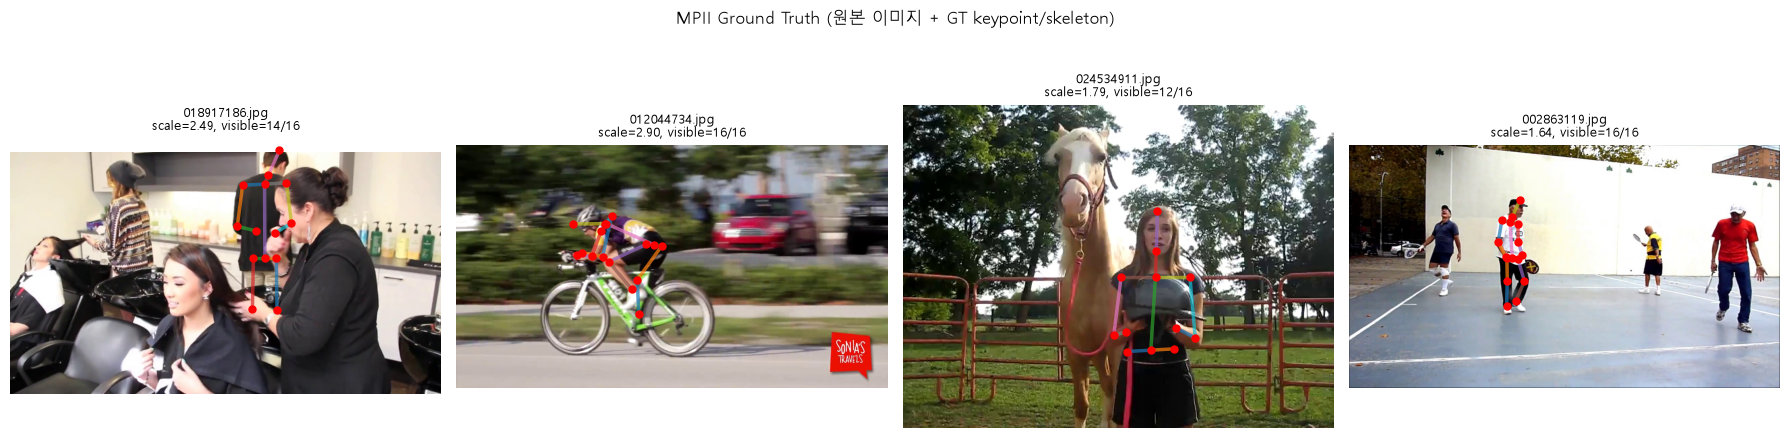

In [9]:
def draw_pose(ax, image, joints, visibility=None, normalized=False, point_size=25):
    """이미지 위에 keypoint 와 skeleton 을 그린다.

    Args:
        ax: matplotlib Axes.
        image: PIL.Image 또는 (H, W, 3) 배열.
        joints: (16, 2) 좌표. normalized=True 면 0~1 정규화 좌표로 해석한다.
        visibility: (16,) 가시성. 0 인 관절은 점을 찍지 않는다. None 이면 전부 표시.
        normalized: joints 가 0~1 정규화 좌표인지 여부.
    """
    image_np = np.asarray(image)
    height, width = image_np.shape[:2]
    ax.imshow(image_np)

    joints = np.asarray(joints, dtype=np.float32)
    if normalized:
        joints = joints * np.array([width, height], dtype=np.float32)

    if visibility is None:
        visibility = np.ones(len(joints), dtype=np.float32)
    visibility = np.asarray(visibility)

    for bone in MPII_BONES:
        a, b = bone
        if visibility[a] > 0 and visibility[b] > 0:
            ax.plot(joints[[a, b], 0], joints[[a, b], 1], linewidth=2.5, alpha=0.7)

    vis_mask = visibility > 0
    ax.scatter(joints[vis_mask, 0], joints[vis_mask, 1], s=point_size, c='red', zorder=3)
    ax.axis('off')


sample_idx = random.Random(SEED).sample(range(len(train_raw)), 4)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, idx in zip(axes, sample_idx):
    anno = train_raw[idx]
    image = Image.open(os.path.join(IMAGE_PATH, anno['image'])).convert('RGB')
    draw_pose(ax, image, anno['joints'], anno['joints_vis'])
    ax.set_title(f"{anno['image']}\nscale={anno['scale']:.2f}, visible={sum(anno['joints_vis'])}/16",
                 fontsize=9)
plt.suptitle('MPII Ground Truth (원본 이미지 + GT keypoint/skeleton)')
plt.tight_layout()
plt.show()

### 2-6. EDA 정리

- **규모** : train 22,246 / valid 2,958 annotation. 고유 이미지는 14,679 / 2,729 장이며 train·valid 간 이미지 중복은 없다.
- **가시성** : annotation 당 평균 14.93 / 16 개가 visible 이고, 16개 전부 보이는 경우는 67.3%.
  가장 자주 가려지는 관절은 발목(0.70) → 무릎(0.83) 순이다. → **하체 말단 관절의 성능이 가장 낮게 나올 것으로 예상**된다.
- **사람 크기** : scale 중앙값 2.89(몸 높이 578px)이지만 최대 24.81(4,963px)까지 퍼져 있다.
  → 고정 크기로 자를 수 없고, **crop margin 을 `scale × 200` 에 비례**해서 잡아야 한다.
- **이미지 해상도** : 1280×720(45.5%) / 1920×1080(28.1%) 이 대부분인 고해상도 사진. 256×256 입력으로 크게 축소된다.
- **이미지당 인물 수** : 평균 1.52명, 29.8%가 2명 이상(최대 13명).
  → 같은 파일을 여러 번 디코딩하게 되므로 데이터 로딩 비용이 annotation 수에 비례해 늘어난다.

**전처리에 반영한 점**

1. 이미지 전체가 아니라 keypoint 를 감싸는 **ROI 를 crop** 해 한 사람만 남긴다(한 이미지에 여러 명이 있으므로 필수).
2. margin 은 `body_height × 비율` 로 잡고, 학습 시에는 0.1~0.3 랜덤으로 뽑아 증강으로 쓴다.
3. `joints_vis == 0` 인 관절은 heatmap 을 만들지 않는다(가려진 관절을 억지로 학습시키지 않기 위해).

---
# 3. 전처리

1. **ptrecord sharding** — 원본 이미지 + annotation 을 직렬화해 여러 개의 샤드 파일로 저장
2. **Preprocessor** — ROI crop → resize → 정규화 → keypoint 를 gaussian heatmap 으로 변환

### 3-1. annotation 파싱

In [10]:
def parse_one_annotation(anno, image_dir):
    """train.json / validation.json 의 annotation 1건에서 필요한 필드만 뽑는다.

    Args:
        anno: json 원소. image / joints / joints_vis / center / scale 을 가진다.
        image_dir: 이미지가 들어있는 디렉터리 경로.

    Returns:
        filename / filepath / joints / joints_visibility / center / scale 을 담은 dict.
    """
    filename = anno['image']
    return {
        'filename': filename,
        'filepath': os.path.join(image_dir, filename),
        'joints': anno['joints'],
        'joints_visibility': anno['joints_vis'],
        'center': anno['center'],
        'scale': anno['scale'],
    }


def load_annotations(annotation_file, image_dir):
    """json 파일 전체를 읽어 parse_one_annotation 을 적용한 리스트를 반환한다."""
    with open(annotation_file, 'r', encoding='utf-8') as f:
        raw = json.load(f)
    return [parse_one_annotation(anno, image_dir) for anno in raw]


parsed = parse_one_annotation(train_raw[0], IMAGE_PATH)
for key, value in parsed.items():
    text = str(value)
    print(f'{key:18s} : {text[:80]}{"..." if len(text) > 80 else ""}')

train_annotations = load_annotations(TRAIN_JSON, IMAGE_PATH)
valid_annotations = load_annotations(VALID_JSON, IMAGE_PATH)
print()
print(f'파싱된 train annotation : {len(train_annotations):,}')
print(f'파싱된 valid annotation : {len(valid_annotations):,}')

filename           : 015601864.jpg
filepath           : .\data\images\015601864.jpg
joints             : [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0],...
joints_visibility  : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
center             : [594.0, 257.0]
scale              : 3.021046

파싱된 train annotation : 22,246
파싱된 valid annotation : 2,958


### 3-2. ptrecord sharding

학습 속도의 병목은 GPU 연산이 아니라 **디스크 I/O** 인 경우가 많다. 그래서 데이터를 하나의 큰 파일이 아니라 여러 개의 작은 파일(**shard**)로 나눠 저장한다.

이번 구현에서 샤드는 **생성·검증까지만** 하고, 실제 학습은 4장의 `MPIIDataset` 이 원본 JPEG 를 직접 읽는다. `num_workers=0` 환경이라 샤드 병렬 읽기의 이점이 없기 때문이다.

In [11]:
import pickle


def generate_ptexample(anno):
    """annotation 1건을 직렬화 가능한 feature dict 로 변환한다.

    JPEG 형식이나 RGB 모드가 아니면 변환 후 재인코딩한다.
    keypoint 는 -1(미표기)도 그대로 보존해야 하므로 정수 변환만 수행한다.
    """
    filepath = anno['filepath']

    with open(filepath, 'rb') as image_file:
        content = image_file.read()

    image = Image.open(filepath)
    if image.format != 'JPEG' or image.mode != 'RGB':
        image_rgb = image.convert('RGB')
        with io.BytesIO() as output:
            image_rgb.save(output, format='JPEG', quality=95)
            content = output.getvalue()

    width, height = image.size

    x = [int(joint[0]) for joint in anno['joints']]
    y = [int(joint[1]) for joint in anno['joints']]
    # MPII 는 0/1 이지만 COCO 관례(2=visible)에 맞춰 0 또는 2 로 저장한다.
    v = [0 if joint_v == 0 else 2 for joint_v in anno['joints_visibility']]

    return {
        'image/height': height,
        'image/width': width,
        'image/depth': 3,
        'image/object/parts/x': x,
        'image/object/parts/y': y,
        'image/object/parts/v': v,
        'image/object/center/x': int(anno['center'][0]),
        'image/object/center/y': int(anno['center'][1]),
        'image/object/scale': anno['scale'],
        'image/encoded': content,
        'image/filename': anno['filename'].encode(),
    }


def chunkify(items, n):
    """리스트를 n 개의 chunk 로 나눈다(= n 개의 샤드 파일). 나머지는 마지막 chunk 에 넣는다."""
    size = len(items) // n
    results = []
    start = 0
    for i in range(n):
        end = start + size if i < n - 1 else len(items)
        results.append(items[start:end])
        start = end
    return results


@ray.remote
def build_single_ptrecord(chunk, path):
    """chunk 하나를 pickle 스트림으로 직렬화해 .ptrecords 파일로 저장한다(ray 병렬 실행)."""
    with open(path, 'wb') as writer:
        for anno in chunk:
            pickle.dump(generate_ptexample(anno), writer)
    return path


def build_pt_records(annotations, total_shards, split, pt_record_path):
    """annotation 리스트를 ray 로 병렬 샤딩해 .ptrecords 파일들을 만든다."""
    os.makedirs(pt_record_path, exist_ok=True)
    chunks = chunkify(annotations, total_shards)
    futures = [
        build_single_ptrecord.remote(
            chunk,
            os.path.join(
                pt_record_path,
                '{}_{}_of_{}.ptrecords'.format(
                    split, str(i + 1).zfill(4), str(total_shards).zfill(4)
                ),
            ),
        )
        for i, chunk in enumerate(chunks)
    ]
    return ray.get(futures)


def ptrecord_status(pt_record_path):
    """이미 생성된 ptrecord 샤드 현황을 요약한다(재생성 여부 판단용)."""
    if not os.path.isdir(pt_record_path):
        return {'exists': False, 'train_shards': 0, 'val_shards': 0, 'total_bytes': 0}

    files = [f for f in os.listdir(pt_record_path) if f.endswith('.ptrecords')]
    return {
        'exists': True,
        'train_shards': len([f for f in files if f.startswith('train')]),
        'val_shards': len([f for f in files if f.startswith('val')]),
        'total_bytes': sum(os.path.getsize(os.path.join(pt_record_path, f)) for f in files),
    }


def read_ptrecord(path):
    """.ptrecords 파일 하나를 읽어 feature dict 리스트로 복원한다(검증용)."""
    features = []
    with open(path, 'rb') as reader:
        while True:
            try:
                features.append(pickle.load(reader))
            except EOFError:
                break
    return features

In [12]:
NUM_TRAIN_SHARDS = 64
NUM_VAL_SHARDS = 8

status = ptrecord_status(PT_RECORD_PATH)
print(f'ptrecord 경로 : {PT_RECORD_PATH}')
print(f'train 샤드 : {status["train_shards"]} / val 샤드 : {status["val_shards"]}')
print(f'총 용량   : {status["total_bytes"] / 1024 ** 3:.2f} GB')

if status['train_shards'] == NUM_TRAIN_SHARDS and status['val_shards'] == NUM_VAL_SHARDS:
    print('\n→ 샤드가 이미 모두 생성되어 있으므로 생성 단계를 건너뛴다.')
else:
    print('\n→ 샤드가 부족하므로 새로 생성한다. (수십 분 소요)')
    ray.shutdown()
    ray.init()

    build_pt_records(train_annotations, NUM_TRAIN_SHARDS, 'train', PT_RECORD_PATH)
    build_pt_records(valid_annotations, NUM_VAL_SHARDS, 'val', PT_RECORD_PATH)

    ray.shutdown()
    print(ptrecord_status(PT_RECORD_PATH))

ptrecord 경로 : .\data\ptrecords_mpii
train 샤드 : 64 / val 샤드 : 8
총 용량   : 11.72 GB

→ 샤드가 이미 모두 생성되어 있으므로 생성 단계를 건너뛴다.


In [13]:
shard_files = sorted(f for f in os.listdir(PT_RECORD_PATH) if f.startswith('train'))
sample_shard = os.path.join(PT_RECORD_PATH, shard_files[0])

records = read_ptrecord(sample_shard)
print(f'{shard_files[0]} : {len(records):,} 레코드, '
      f'{os.path.getsize(sample_shard) / 1024 ** 2:.1f} MB')
print()

record = records[0]
for key, value in record.items():
    if key == 'image/encoded':
        print(f'{key:26s} : <JPEG bytes> {len(value):,} bytes')
    else:
        print(f'{key:26s} : {value}')

# 저장된 JPEG 바이트가 정상적으로 디코딩되는지 확인
decoded = Image.open(io.BytesIO(record['image/encoded']))
print(f'\n디코딩 확인 : {decoded.size}, mode={decoded.mode}')

train_0001_of_0064.ptrecords : 347 레코드, 138.9 MB

image/height               : 720
image/width                : 1280
image/depth                : 3
image/object/parts/x       : [620, 616, 573, 647, 661, 656, 610, 647, 637, 695, 606, 553, 601, 692, 693, 688]
image/object/parts/y       : [394, 269, 185, 188, 221, 231, 187, 176, 189, 108, 217, 161, 167, 185, 240, 313]
image/object/center/x      : 594
image/object/center/y      : 257
image/object/scale         : 3.021046
image/object/parts/v       : [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
image/encoded              : <JPEG bytes> 225,464 bytes
image/filename             : b'015601864.jpg'

디코딩 확인 : (1280, 720), mode=RGB


### 3-3. Preprocessor

1. **`crop_roi`** — 유효한 keypoint 를 모두 감싸는 박스에 `body_height × margin` 만큼 여백을 더해 crop.
   - 학습 시에는 margin 을 0.1~0.3 에서 랜덤으로 뽑아 **증강**으로 사용한다.
   - crop box 가 이미지 밖으로 나가지 않도록 clamp 해야 한다.
2. **resize + 정규화** — 256×256 으로 resize 후 `[-1, 1]` 범위로 정규화하고 `(C, H, W)` 로 전치.
3. **`make_heatmaps`** — (x, y) 좌표 하나를 그 주변의 확률 분포(2D 가우시안)로 바꿔 64×64 heatmap 16장 생성.
   - `joints_vis == 0` 인 관절은 전부 0 인 heatmap 이 된다.

In [14]:
class Preprocessor:
    """원본 이미지 + annotation 을 (이미지 텐서, heatmap 텐서) 로 변환한다.

    Args:
        image_shape: (H, W, C). 모델 입력 크기.
        heatmap_shape: (H, W, num_heatmap). 출력 heatmap 크기.
        is_train: True 면 crop margin 을 0.1~0.3 사이에서 랜덤 샘플링(증강).
        sigma: 가우시안 표준편차.
        scale: 가우시안 peak 값.
    """

    def __init__(self, image_shape=(256, 256, 3), heatmap_shape=(64, 64, 16),
                 is_train=False, sigma=1, scale=12):
        self.image_shape = image_shape
        self.heatmap_shape = heatmap_shape
        self.is_train = is_train
        self.sigma = sigma
        self.scale = scale

    def __call__(self, image, annotation):
        margin = random.uniform(0.1, 0.3) if self.is_train else 0.2
        cropped, keypoint_x, keypoint_y = self.crop_roi(image, annotation, margin=margin)
        cropped = cropped.resize((self.image_shape[1], self.image_shape[0]))

        # [0, 255] -> [-1, 1] 정규화 후 (H, W, C) -> (C, H, W)
        image_np = np.asarray(cropped, dtype=np.float32) / 127.5 - 1.0
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).contiguous()

        visibility = annotation.get('joints_visibility', annotation.get('joints_vis'))
        heatmaps = self.make_heatmaps(keypoint_x, keypoint_y, visibility)

        return image_tensor, heatmaps

    def crop_roi(self, image, annotation, margin=0.2):
        """keypoint 를 감싸는 ROI 를 잘라내고 keypoint 를 0~1 로 정규화한다."""
        img_width, img_height = image.size

        joints = annotation['joints']
        keypoint_x = torch.tensor([j[0] for j in joints], dtype=torch.float32)
        keypoint_y = torch.tensor([j[1] for j in joints], dtype=torch.float32)
        body_height = annotation['scale'] * SCALE_TO_PIXEL

        valid = (keypoint_x > 0) & (keypoint_y > 0)
        extra = int(body_height * margin)

        if bool(valid.any()):
            xmin = int(keypoint_x[valid].min().item()) - extra
            xmax = int(keypoint_x[valid].max().item()) + extra
            ymin = int(keypoint_y[valid].min().item()) - extra
            ymax = int(keypoint_y[valid].max().item()) + extra
        else:
            # 유효 keypoint 가 전무한 예외 샘플: center/scale 로 박스를 만든다.
            center_x, center_y = annotation['center']
            half = int(body_height / 2) + extra
            xmin, xmax = int(center_x) - half, int(center_x) + half
            ymin, ymax = int(center_y) - half, int(center_y) + half

        # crop box 가 이미지 밖으로 나가지 않도록 clamp
        effective_xmin = max(xmin, 0)
        effective_ymin = max(ymin, 0)
        effective_xmax = min(xmax, img_width)
        effective_ymax = min(ymax, img_height)

        # 폭/높이가 0 이 되는 것을 방지(좌표가 이미지 밖인 병리적 샘플 대비)
        if effective_xmax <= effective_xmin:
            effective_xmin, effective_xmax = 0, img_width
        if effective_ymax <= effective_ymin:
            effective_ymin, effective_ymax = 0, img_height

        cropped = image.crop((effective_xmin, effective_ymin,
                              effective_xmax, effective_ymax))
        new_width = effective_xmax - effective_xmin
        new_height = effective_ymax - effective_ymin

        effective_keypoint_x = (keypoint_x - effective_xmin) / new_width
        effective_keypoint_y = (keypoint_y - effective_ymin) / new_height

        return cropped, effective_keypoint_x, effective_keypoint_y

    def generate_2d_gaussian(self, height, width, y0, x0, visibility=2):
        """(height, width) heatmap 의 (x0, y0) 위치에 2D 가우시안을 그린다.

        좌표가 heatmap 밖이거나 visibility 가 0 이면 전부 0 인 heatmap 을 돌려준다.
        """
        heatmap = torch.zeros((height, width), dtype=torch.float32)

        sigma = self.sigma
        xmin, ymin = x0 - 3 * sigma, y0 - 3 * sigma
        xmax, ymax = x0 + 3 * sigma, y0 + 3 * sigma

        if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
            return heatmap

        size = int(6 * sigma + 1)
        grid_range = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
        center = size // 2
        gaussian_patch = torch.exp(
            -(((x_grid - center) ** 2 + (y_grid - center) ** 2) / (2 * sigma ** 2))
        ) * self.scale

        # heatmap 과 patch 가 겹치는 영역만 잘라서 대입
        patch_xmin, patch_ymin = max(0, -xmin), max(0, -ymin)
        patch_xmax = min(xmax, width) - xmin
        patch_ymax = min(ymax, height) - ymin

        heatmap_xmin, heatmap_ymin = max(0, xmin), max(0, ymin)
        heatmap_xmax, heatmap_ymax = min(xmax, width), min(ymax, height)

        heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
            gaussian_patch[int(patch_ymin):int(patch_ymax),
                           int(patch_xmin):int(patch_xmax)]
        return heatmap

    def make_heatmaps(self, keypoint_x, keypoint_y, visibility):
        """정규화된 keypoint 좌표들로 (num_heatmap, H, W) heatmap 스택을 만든다."""
        heatmap_h, heatmap_w, num_heatmap = self.heatmap_shape

        x = torch.round(keypoint_x * heatmap_w).to(torch.int32)
        y = torch.round(keypoint_y * heatmap_h).to(torch.int32)
        v = torch.tensor(visibility, dtype=torch.float32)

        heatmaps = [
            self.generate_2d_gaussian(
                heatmap_h, heatmap_w,
                y0=int(y[i].item()), x0=int(x[i].item()),
                visibility=int(v[i].item()),
            )
            for i in range(num_heatmap)
        ]
        return torch.stack(heatmaps, dim=0)

image_tensor : (3, 256, 256)  dtype=torch.float32  range=[-1.00, 1.00]
heatmaps     : (16, 64, 64)  dtype=torch.float32  range=[0.00, 12.00]
0 이 아닌 heatmap 채널 수 : 14 / 16  (visible 관절 수 : 14)


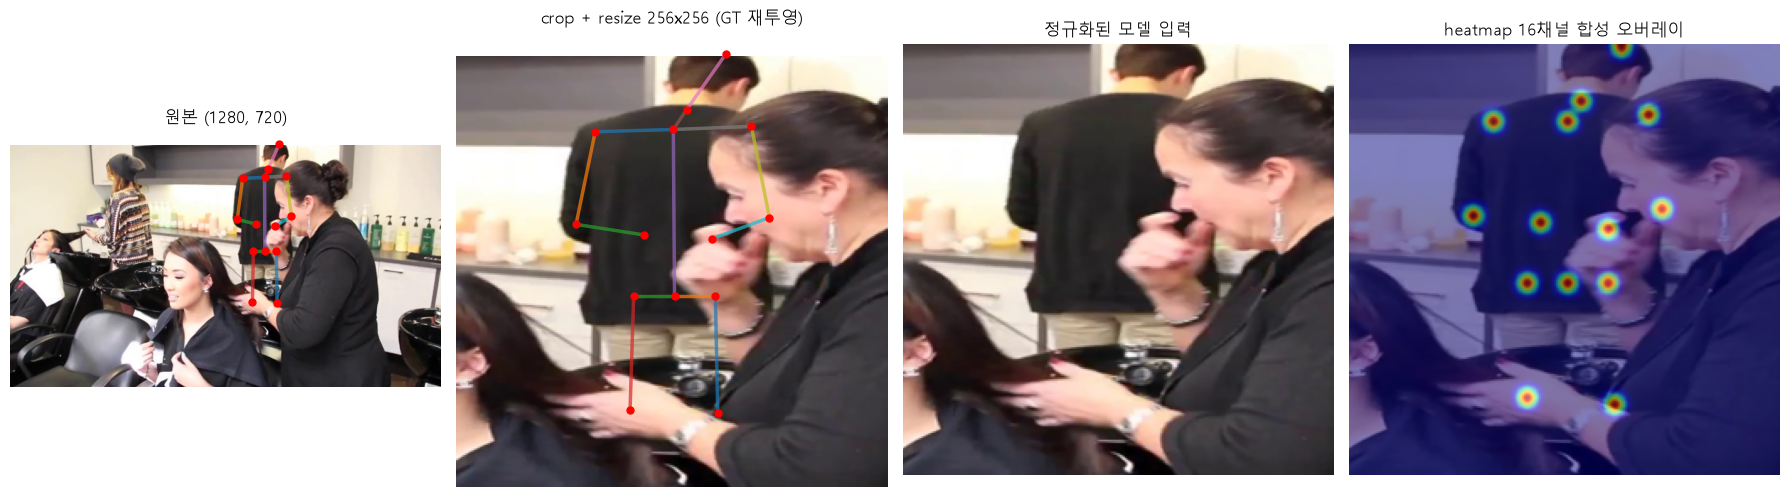

In [15]:
# 샘플 하나를 통과시켜 전처리가 정상적으로 동작하는지 확인

preprocess_valid = Preprocessor(image_shape=IMAGE_SHAPE,
                                heatmap_shape=(*HEATMAP_SIZE, NUM_HEATMAP),
                                is_train=False)

anno = train_annotations[sample_idx[0]]
original = Image.open(anno['filepath']).convert('RGB')

image_tensor, heatmaps = preprocess_valid(original, anno)
print(f'image_tensor : {tuple(image_tensor.shape)}  dtype={image_tensor.dtype}  '
      f'range=[{image_tensor.min():.2f}, {image_tensor.max():.2f}]')
print(f'heatmaps     : {tuple(heatmaps.shape)}  dtype={heatmaps.dtype}  '
      f'range=[{heatmaps.min():.2f}, {heatmaps.max():.2f}]')
print(f'0 이 아닌 heatmap 채널 수 : {(heatmaps.amax(dim=(1, 2)) > 0).sum().item()} / {NUM_HEATMAP}'
      f'  (visible 관절 수 : {sum(anno["joints_visibility"])})')


def tensor_to_image(tensor):
    """[-1, 1] 정규화된 (C, H, W) 텐서를 화면 표시용 (H, W, C) 배열로 되돌린다."""
    return ((tensor.permute(1, 2, 0).numpy() + 1.0) / 2.0).clip(0, 1)


def heatmap_overlay(heatmaps, size):
    """heatmap 16채널을 하나로 합쳐 이미지 크기로 확대한 오버레이 배열을 만든다."""
    merged = heatmaps.amax(dim=0).numpy()
    merged = (merged / max(merged.max(), 1e-6) * 255).astype(np.uint8)
    return np.array(Image.fromarray(merged).resize(size))


# crop 결과에 GT 를 다시 얹어 좌표 변환이 맞는지 확인
cropped, kx, ky = preprocess_valid.crop_roi(original, anno, margin=0.2)
resized = cropped.resize((IMAGE_SHAPE[1], IMAGE_SHAPE[0]))
norm_joints = np.stack([kx.numpy(), ky.numpy()], axis=1)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
draw_pose(axes[0], original, anno['joints'], anno['joints_visibility'])
axes[0].set_title(f'원본 {original.size}')

draw_pose(axes[1], resized, norm_joints, anno['joints_visibility'], normalized=True)
axes[1].set_title('crop + resize 256x256 (GT 재투영)')

axes[2].imshow(tensor_to_image(image_tensor))
axes[2].set_title('정규화된 모델 입력')
axes[2].axis('off')

axes[3].imshow(tensor_to_image(image_tensor))
axes[3].imshow(heatmap_overlay(heatmaps, (IMAGE_SHAPE[1], IMAGE_SHAPE[0])),
               alpha=0.5, cmap='jet')
axes[3].set_title('heatmap 16채널 합성 오버레이')
axes[3].axis('off')
plt.tight_layout()
plt.show()

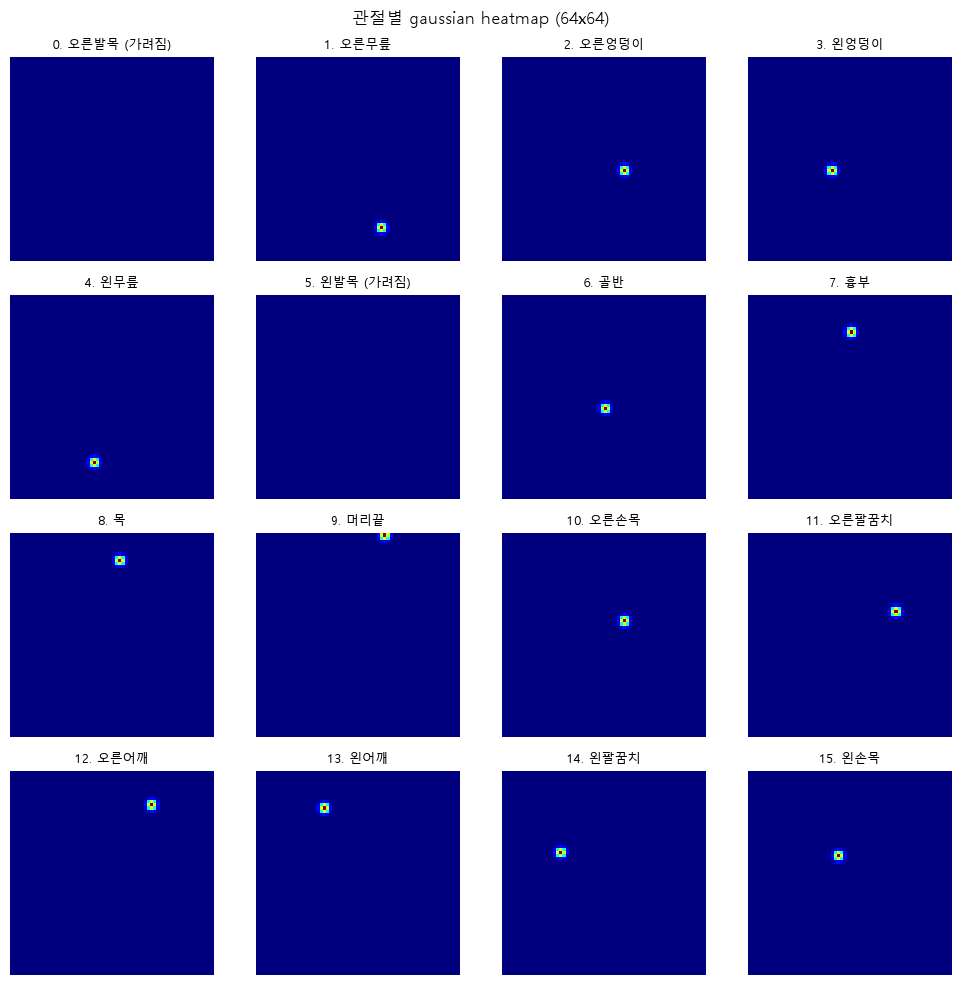

In [16]:
# 관절별 heatmap 을 개별로 확인
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(heatmaps[i].numpy(), cmap='jet', vmin=0, vmax=12)
    visible = anno['joints_visibility'][i]
    ax.set_title(f'{i}. {JOINT_NAMES_KO[i]}' + ('' if visible else ' (가려짐)'), fontsize=9)
    ax.axis('off')
plt.suptitle('관절별 gaussian heatmap (64x64)')
plt.tight_layout()
plt.show()

---
# 4. 데이터셋 · DataLoader 구축

`MPIIDataset` 이 이미지를 읽고 `Preprocessor` 가 학습 형태로 바꾼 뒤 `DataLoader` 가 배치로 묶는다. 두 모델이 **같은 데이터를 같은 순서로** 보도록, DataLoader 는 `create_dataloader()` 하나로만 만든다.

- `make_subset_indices()` 는 seed 를 고정해 부분집합을 뽑는다. 학습 규모를 줄여야 할 때, 두 모델에 **완전히 동일한** 부분집합을 공급하기 위한 장치다.
- `return_meta=True` 면 평가에 필요한 원본 좌표·가시성·scale 을 함께 돌려준다.

In [17]:
from torch.utils.data import DataLoader, Dataset


def make_subset_indices(total, subset_size, seed=SEED):
    """전체 인덱스에서 seed 를 고정해 subset_size 개를 뽑는다.

    subset_size 가 None 이거나 전체보다 크면 전체 인덱스를 그대로 반환한다.
    """
    if subset_size is None or subset_size >= total:
        return list(range(total))
    rng = random.Random(seed)
    return sorted(rng.sample(range(total), subset_size))


class MPIIDataset(Dataset):
    """MPII annotation + 원본 이미지를 읽어 (image, heatmaps) 를 돌려주는 Dataset.

    Args:
        annotations: parse 된 annotation 리스트.
        transform: Preprocessor 인스턴스. None 이면 (PIL 이미지, annotation) 원본 반환.
        indices: 사용할 annotation 인덱스 목록(서브셋 학습용). None 이면 전체.
        return_meta: True 면 평가(PCK)용 메타데이터까지 함께 반환.
    """

    def __init__(self, annotations, transform=None, indices=None, return_meta=False):
        self.transform = transform
        self.return_meta = return_meta
        self.annotations = ([annotations[i] for i in indices]
                            if indices is not None else annotations)

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        image = Image.open(anno['filepath']).convert('RGB')

        if self.transform is None:
            return image, anno

        image_tensor, heatmaps = self.transform(image, anno)
        if not self.return_meta:
            return image_tensor, heatmaps

        meta = {
            'joints': torch.tensor(anno['joints'], dtype=torch.float32),
            'joints_visibility': torch.tensor(anno['joints_visibility'],
                                              dtype=torch.float32),
            'scale': torch.tensor(anno['scale'], dtype=torch.float32),
        }
        return image_tensor, heatmaps, meta


def create_dataloader(annotations, batch_size, num_heatmap=NUM_HEATMAP, is_train=True,
                      num_workers=0, image_shape=IMAGE_SHAPE, heatmap_size=HEATMAP_SIZE,
                      subset_size=None, seed=SEED, return_meta=False):
    """학습/검증용 DataLoader 를 만든다.

    이 환경(Windows + Jupyter)에서는 num_workers=0 만 사용한다. 워커가 spawn 으로 뜨는데
    자식 프로세스가 노트북 `__main__` 의 MPIIDataset / Preprocessor 를 가져오지 못해
    pickle 에 실패하기 때문이다. 분기 코드는 다른 환경에서 재사용할 수 있도록 남겨둔다.
    """
    preprocess = Preprocessor(
        image_shape=image_shape,
        heatmap_shape=(heatmap_size[0], heatmap_size[1], num_heatmap),
        is_train=is_train,
    )

    indices = make_subset_indices(len(annotations), subset_size, seed=seed)
    dataset = MPIIDataset(annotations, transform=preprocess, indices=indices,
                          return_meta=return_meta)

    loader_kwargs = dict(
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=is_train,
    )
    if num_workers > 0:
        loader_kwargs.update(prefetch_factor=2, persistent_workers=True)

    return DataLoader(dataset, **loader_kwargs)

In [18]:
set_seed(SEED)

train_loader = create_dataloader(train_annotations, batch_size=BATCH_SIZE, is_train=True,
                                 num_workers=0)
valid_loader = create_dataloader(valid_annotations, batch_size=BATCH_SIZE, is_train=False,
                                 num_workers=0)

print(f'train : {len(train_loader.dataset):,} 샘플 / {len(train_loader):,} 배치')
print(f'valid : {len(valid_loader.dataset):,} 샘플 / {len(valid_loader):,} 배치')

images, labels = next(iter(train_loader))
print()
print(f'images : {tuple(images.shape)}  {images.dtype}  '
      f'range=[{images.min():.2f}, {images.max():.2f}]')
print(f'labels : {tuple(labels.shape)}  {labels.dtype}  '
      f'range=[{labels.min():.2f}, {labels.max():.2f}]')
print(f'label 이 0 이 아닌 픽셀 비율 : {(labels > 0).float().mean():.4f}')

train : 22,246 샘플 / 1,390 배치
valid : 2,958 샘플 / 185 배치

images : (16, 3, 256, 256)  torch.float32  range=[-1.00, 1.00]
labels : (16, 16, 64, 64)  torch.float32  range=[0.00, 12.00]
label 이 0 이 아닌 픽셀 비율 : 0.0080


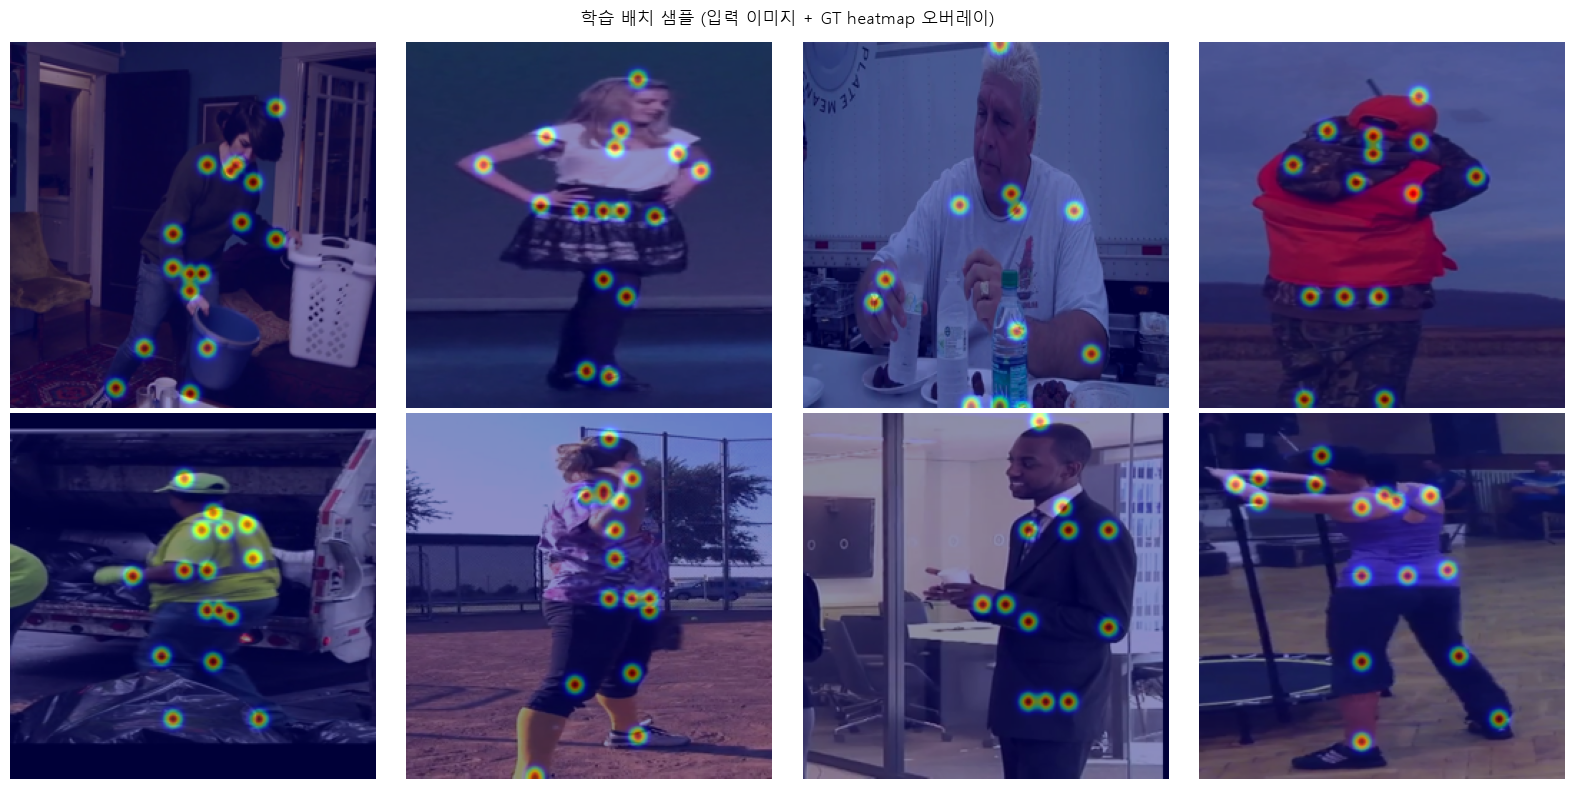

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(tensor_to_image(images[i]))
    ax.imshow(heatmap_overlay(labels[i], (IMAGE_SHAPE[1], IMAGE_SHAPE[0])),
              alpha=0.45, cmap='jet')
    ax.axis('off')
plt.suptitle('학습 배치 샘플 (입력 이미지 + GT heatmap 오버레이)')
plt.tight_layout()
plt.show()

### 4-1. 학습 규모 결정

학습 규모는 **StackedHourglass 로 1 epoch 을 실제로 돌려본 뒤** 결정한다. 1 epoch 이 30분을 넘기면 `TRAIN_SUBSET_SIZE` 를 줄인다. `make_subset_indices()` 가 seed 를 고정하므로 **두 모델에 완전히 동일한 부분집합**이 공급된다.

In [20]:
# 우선 전체 데이터로 1 epoch 을 돌려보고, 30분을 넘기면 줄인다.
TRAIN_SUBSET_SIZE = None
VALID_SUBSET_SIZE = None

NUM_WORKERS = 0

train_size = len(make_subset_indices(len(train_annotations), TRAIN_SUBSET_SIZE))
valid_size = len(make_subset_indices(len(valid_annotations), VALID_SUBSET_SIZE))
steps_per_epoch = train_size // BATCH_SIZE

print(f'학습에 사용할 train 샘플 : {train_size:,} / {len(train_annotations):,}')
print(f'학습에 사용할 valid 샘플 : {valid_size:,} / {len(valid_annotations):,}')
print(f'1 epoch 배치 수 : {steps_per_epoch:,}')
print(f'batch_size {BATCH_SIZE} / epochs {EPOCHS} / lr {LEARNING_RATE} / num_workers {NUM_WORKERS}')

학습에 사용할 train 샘플 : 22,246 / 22,246
학습에 사용할 valid 샘플 : 2,958 / 2,958
1 epoch 배치 수 : 1,390
batch_size 16 / epochs 5 / lr 0.0007 / num_workers 0


---
# 5. StackedHourglass Network 구현

Hourglass 는 **encoder 와 decoder 가 대칭**인 모듈을 여러 개 쌓은 구조다. 구성 요소는 세 가지다.

1. **`BottleneckBlock`** — 1x1 → 3x3 → 1x1 residual block. 채널이 바뀌는 지점에서는 identity 쪽에 1x1 conv 를 둔다.
2. **`HourglassModule`** — 해상도를 반으로 줄였다가 다시 키우는 모듈. 바깥 껍질을 벗기면 같은 구조가 나오는
   **재귀 구조**라, `order` 를 하나씩 줄여가며 자기 자신을 호출하고 `order == 1` 에서 BottleneckBlock 으로 끝낸다.
3. **`LinearLayer`** — 1x1 conv + BN + ReLU. 스택 사이에서 중간 heatmap 을 뽑을 때 쓴다.

In [21]:
import torch.nn as nn


class BottleneckBlock(nn.Module):
    """1x1 - 3x3 - 1x1 형태의 pre-activation residual block.

    Args:
        in_channels: 입력 채널 수.
        filters: 출력 채널 수.
        stride: 3x3 conv 의 stride.
        downsample: True 면 identity 쪽에도 1x1 conv 를 적용해 채널/해상도를 맞춘다.
    """

    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        if self.downsample:
            # identity branch 의 채널 수와 spatial size 를 main branch 에 맞춘다
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1,
                                             stride=stride, bias=False)

        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1,
                               padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride,
                               padding=1, bias=False)   # padding=1 로 'same' 효과

        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1,
                               padding=0, bias=False)

    def forward(self, x):
        identity = self.downsample_conv(x) if self.downsample else x

        out = self.conv1(self.relu(self.bn1(x)))
        out = self.conv2(self.relu(self.bn2(out)))
        out = self.conv3(self.relu(self.bn3(out)))

        return out + identity

In [22]:
class HourglassModule(nn.Module):
    """해상도를 절반으로 줄였다 되돌리는 hourglass 모듈(재귀 구조).

    up branch 는 해상도를 유지한 채 residual block 을 통과하고,
    low branch 는 pooling 으로 절반으로 줄인 뒤 order-1 짜리 hourglass 를 다시 통과한다.
    order == 1 이면 재귀를 멈추고 BottleneckBlock 으로 대체한다.
    마지막에 upsampling 한 low branch 와 up branch 를 더해 skip connection 을 만든다.

    Args:
        order: 껍질 수. 4 면 64 -> 32 -> 16 -> 8 -> 4 까지 내려간다.
        filters: 채널 수(전 구간 동일).
        num_residual: 각 지점에서 반복할 residual block 수.
    """

    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order

        def make_blocks():
            return nn.Sequential(*[
                BottleneckBlock(in_channels=filters, filters=filters, stride=1,
                                downsample=False)
                for _ in range(num_residual)
            ])

        # up branch : 해상도 유지
        self.up1_0 = BottleneckBlock(in_channels=filters, filters=filters, stride=1,
                                     downsample=False)
        self.up1_blocks = make_blocks()

        # low branch : 1/2 로 축소
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = make_blocks()

        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)   # 재귀
        else:
            self.low2_blocks = make_blocks()                                # 재귀 종료

        self.low3_blocks = make_blocks()
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up1 = self.up1_blocks(self.up1_0(x))

        low1 = self.low1_blocks(self.pool(x))
        low2 = self.low2(low1) if self.order > 1 else self.low2_blocks(low1)
        up2 = self.upsample(self.low3_blocks(low2))

        return up2 + up1


class LinearLayer(nn.Module):
    """1x1 conv + BN + ReLU. 스택 사이에서 feature 를 정리할 때 사용한다."""

    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1,
                              padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

앞의 부품들을 조립해 전체 네트워크를 만든다.

- **stem** : 7x7 conv(stride 2) → BottleneckBlock → maxpool → BottleneckBlock ×2
  로 256×256 입력을 **64×64×256** 으로 줄인다. 이후 hourglass 스택은 해상도를 유지하므로,
  최종 출력이 heatmap 크기인 **64×64** 가 된다.
- **stack** : `HourglassModule(order=4)` → residual → `LinearLayer` → 1x1 conv 로 heatmap 을 뽑는다.
- 마지막 스택이 아니면, feature 와 heatmap 을 각각 1x1 conv 로 되돌려 더한 뒤 **다음 스택의 입력**으로 넘긴다.

In [23]:
class StackedHourglassNetwork(nn.Module):
    """Stacked Hourglass Network.

    Args:
        input_shape: (H, W, C) 입력 형태.
        num_stack: 쌓을 hourglass 모듈 수. 스택마다 heatmap 을 내보낸다.
        num_residual: hourglass 내부에서 반복할 residual block 수.
        num_heatmap: 출력 heatmap 채널 수(= keypoint 수).

    Returns:
        forward() 는 스택별 heatmap 리스트를 반환한다(intermediate supervision).
    """

    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1,
                 num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        # ---- stem : 256x256 -> 64x64, 채널 3 -> 256 ----
        self.conv1 = nn.Conv2d(input_shape[2], 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        self.bottleneck1 = BottleneckBlock(64, 128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck2 = BottleneckBlock(128, 128, stride=1, downsample=False)
        self.bottleneck3 = BottleneckBlock(128, 256, stride=1, downsample=True)

        # ---- stack 구성 요소 ----
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        self.intermediate_convs = nn.ModuleList()   # 마지막 스택 제외
        self.intermediate_outs = nn.ModuleList()

        for i in range(num_stack):
            self.hourglass_modules.append(
                HourglassModule(order=4, filters=256, num_residual=num_residual))
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(256, 256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            self.linear_layers.append(LinearLayer(256, 256))
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1))

            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1))

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)   # 스택마다 heatmap 출력 -> intermediate loss

            if i < self.num_stack - 1:
                # feature 와 heatmap 을 각각 되돌려 더한 값이 다음 스택의 입력이 된다
                x = self.intermediate_convs[i](lin) + self.intermediate_outs[i](heatmap)

        return outputs

In [24]:
# 모델이 의도한 형태를 내놓는지 확인한다.
def count_parameters(model):
    """학습 가능한 파라미터 수를 계산한다."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


set_seed(SEED)
hourglass = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1,
                                    num_heatmap=NUM_HEATMAP).to(DEVICE)

dummy = torch.randn(2, 3, IMAGE_SHAPE[0], IMAGE_SHAPE[1], device=DEVICE)
hourglass.eval()
with torch.no_grad():
    outputs = hourglass(dummy)

print(f'입력          : {tuple(dummy.shape)}')
print(f'출력 개수     : {len(outputs)} (= num_stack, 스택마다 heatmap 1개)')
print(f'출력 shape    : {[tuple(o.shape) for o in outputs]}')

HOURGLASS_PARAMS = count_parameters(hourglass)
print(f'파라미터 수   : {HOURGLASS_PARAMS:,} ({HOURGLASS_PARAMS / 1e6:.1f}M)')

del hourglass, outputs, dummy
if torch.cuda.is_available():
    torch.cuda.empty_cache()

입력          : (2, 3, 256, 256)
출력 개수     : 4 (= num_stack, 스택마다 heatmap 1개)
출력 shape    : [(2, 16, 64, 64), (2, 16, 64, 64), (2, 16, 64, 64), (2, 16, 64, 64)]
파라미터 수   : 16,251,392 (16.3M)


---
# 6. SimpleBaseline 구현

| | StackedHourglass | SimpleBaseline |
|---|---|---|
| 구조 | multi-stage (스택 4개) | **1-stage** |
| encoder / decoder | 거의 대칭 | **무거운 encoder(ResNet50) + 가벼운 decoder(deconv 3개)** |
| skip connection | 있음 | **없음** |
| supervision | 스택마다 (intermediate) | 최종 출력 1회 |

### 구조 (논문 + 공식 구현 기준)

```
입력 256x256x3
  └ ResNet50 (layer4 까지, avgpool/fc 제거)      -> 8 x 8 x 2048
  └ deconv x3 : ConvTranspose2d(k=4, s=2, p=1) + BN + ReLU, 채널 256
        8x8 -> 16x16 -> 32x32 -> 64x64
  └ final_layer : Conv2d(256, 16, k=1)          -> 64 x 64 x 16
```

In [25]:
from torchvision.models import ResNet50_Weights, resnet50

BN_MOMENTUM = 0.1   # 공식 구현값


class SimpleBaseline(nn.Module):
    """Simple Baselines for Human Pose Estimation.

    ResNet50 encoder + 3단 deconv decoder 로 이루어진 1-stage 모델.

    Args:
        input_shape: (H, W, C) 입력 형태.
        num_heatmap: 출력 heatmap 채널 수(MPII 는 16).
        num_deconv_layers: deconv 단 수(논문 기본값 3).
        deconv_filters: deconv 채널 수(논문 기본값 256).
        deconv_kernel: deconv 커널 크기(논문 기본값 4).
        pretrained: True 면 ImageNet 사전학습 ResNet50 가중치 사용.

    Returns:
        forward() 는 heatmap 하나를 담은 리스트를 반환.
    """

    def __init__(self, input_shape=(256, 256, 3), num_heatmap=16, num_deconv_layers=3,
                 deconv_filters=256, deconv_kernel=4, pretrained=True):
        super(SimpleBaseline, self).__init__()

        weights = ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        try:
            backbone = resnet50(weights=weights)
        except Exception as exc:
            # 가중치 다운로드가 안 되는 오프라인 환경 대비
            print(f'사전학습 가중치를 불러오지 못해 랜덤 초기화로 진행한다: {exc}')
            backbone = resnet50(weights=None)

        # avgpool 과 fc 를 제거하고 layer4 까지만 encoder 로 사용한다
        self.encoder = nn.Sequential(*list(backbone.children())[:-2])
        self.deconv_layers = self._make_deconv_layer(
            2048, num_deconv_layers, deconv_filters, deconv_kernel)
        self.final_layer = nn.Conv2d(deconv_filters, num_heatmap, kernel_size=1,
                                     stride=1, padding=0)

        self._init_decoder_weights()

    @staticmethod
    def _make_deconv_layer(in_channels, num_layers, filters, kernel):
        """deconv-BN-ReLU 를 num_layers 번 쌓는다. 매 단마다 해상도가 2배가 된다."""
        layers = []
        for _ in range(num_layers):
            layers.append(nn.ConvTranspose2d(in_channels, filters, kernel_size=kernel,
                                             stride=2, padding=1, output_padding=0,
                                             bias=False))
            layers.append(nn.BatchNorm2d(filters, momentum=BN_MOMENTUM))
            layers.append(nn.ReLU(inplace=True))
            in_channels = filters
        return nn.Sequential(*layers)

    def _init_decoder_weights(self):
        """decoder 만 초기화한다. encoder 는 사전학습 가중치를 그대로 둔다."""
        for module in self.deconv_layers.modules():
            if isinstance(module, nn.ConvTranspose2d):
                nn.init.normal_(module.weight, std=0.001)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

        nn.init.normal_(self.final_layer.weight, std=0.001)
        nn.init.constant_(self.final_layer.bias, 0)

    def forward(self, x):
        x = self.encoder(x)          # (B, 2048, 8, 8)
        x = self.deconv_layers(x)    # (B, 256, 64, 64)
        out = self.final_layer(x)    # (B, num_heatmap, 64, 64)
        return [out]                 # 학습 코드의 loss 루프와 호환되도록 리스트로 반환

In [26]:
# 단계별 출력 크기가 설계대로인지 확인한다.
set_seed(SEED)
simplebaseline = SimpleBaseline(IMAGE_SHAPE, num_heatmap=NUM_HEATMAP).to(DEVICE)

dummy = torch.randn(2, 3, IMAGE_SHAPE[0], IMAGE_SHAPE[1], device=DEVICE)
simplebaseline.eval()
with torch.no_grad():
    encoded = simplebaseline.encoder(dummy)
    decoded = simplebaseline.deconv_layers(encoded)
    outputs = simplebaseline(dummy)

print(f'입력            : {tuple(dummy.shape)}')
print(f'ResNet50 출력   : {tuple(encoded.shape)}')
print(f'deconv 출력     : {tuple(decoded.shape)}')
print(f'최종 출력 개수  : {len(outputs)} (1-stage 이므로 1개)')
print(f'최종 출력 shape : {[tuple(o.shape) for o in outputs]}')

SIMPLEBASELINE_PARAMS = count_parameters(simplebaseline)
print(f'파라미터 수     : {SIMPLEBASELINE_PARAMS:,} ({SIMPLEBASELINE_PARAMS / 1e6:.1f}M)')

del simplebaseline, outputs, encoded, decoded, dummy
if torch.cuda.is_available():
    torch.cuda.empty_cache()

입력            : (2, 3, 256, 256)
ResNet50 출력   : (2, 2048, 8, 8)
deconv 출력     : (2, 256, 64, 64)
최종 출력 개수  : 1 (1-stage 이므로 1개)
최종 출력 shape : [(2, 16, 64, 64)]
파라미터 수     : 33,999,440 (34.0M)


In [27]:
print(f'{"":16s} {"StackedHourglass":>18s} {"SimpleBaseline":>16s}')
print(f'{"파라미터 수":14s} {HOURGLASS_PARAMS:>18,} {SIMPLEBASELINE_PARAMS:>16,}')
print(f'{"stage 수":16s} {4:>18d} {1:>16d}')
print(f'{"출력 heatmap":15s} {"4 x (16,64,64)":>18s} {"1 x (16,64,64)":>16s}')
print(f'{"사전학습":16s} {"없음":>17s} {"ImageNet ResNet50":>15s}')
print()
print(f'파라미터 수 비율 : SimpleBaseline 이 Hourglass 의 '
      f'{SIMPLEBASELINE_PARAMS / HOURGLASS_PARAMS:.2f} 배')

                   StackedHourglass   SimpleBaseline
파라미터 수                 16,251,392       33,999,440
stage 수                           4                1
출력 heatmap          4 x (16,64,64)   1 x (16,64,64)
사전학습                            없음 ImageNet ResNet50

파라미터 수 비율 : SimpleBaseline 이 Hourglass 의 2.09 배


---
# 7. 학습

두 모델을 동일한 조건으로 학습한다.

| 항목 | 값 |
|---|---|
| epochs | 3 |
| batch size | 16 |
| learning rate | 7e-4 |
| optimizer | Adam |
| warmup | 500 step linear |
| loss | weighted MSE |
| 데이터 | 동일 subset·동일 seed |

### loss 비교 시 주의

Hourglass 는 스택마다 heatmap 을 내보내므로 loss 가 **4번 더해진다.** SimpleBaseline 은 1번이다.
두 모델의 loss 를 그대로 비교하면 Hourglass 가 4배 불리해 보이므로,
history 에 **출력 개수로 나눈 `*_per_output` 값**을 함께 기록해 이 값으로 비교한다.

In [28]:
import time

from tqdm.auto import tqdm


class Trainer:
    """heatmap 회귀 모델 학습기.

    Args:
        model: 학습할 nn.Module. forward 가 heatmap 리스트를 반환해야 한다.
        epochs: 학습 epoch 수.
        global_batch_size: loss 스케일에 쓰는 배치 크기(원본과 동일).
        initial_learning_rate: 초기 학습률.
        tag: 체크포인트/history 파일 이름에 붙일 모델 이름.
        warmup_steps: 학습률을 0 에서 선형으로 끌어올릴 step 수.
        use_amp: bfloat16 AMP 사용 여부.
    """

    def __init__(self, model, epochs, global_batch_size, initial_learning_rate,
                 tag='model', device=DEVICE, warmup_steps=500, use_amp=True,
                 max_patience=10):
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size
        self.tag = tag
        self.device = device
        self.warmup_steps = warmup_steps
        self.use_amp = use_amp and device.type == 'cuda'

        self.optimizer = torch.optim.Adam(model.parameters(), lr=initial_learning_rate)

        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = max_patience

        self.global_step = 0
        self.num_outputs = 1
        self.best_model = None
        self.history = []

    # ---------------- learning rate ----------------
    def lr_decay(self):
        """val loss 가 개선되지 않으면 학습률을 1/10 로 줄인다."""
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0

        self.patience_count += 1
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def lr_decay_step(self, epoch):
        """epoch 25/50/75 에서 학습률을 1/10 로 줄인다."""
        if epoch in [25, 50, 75]:
            self.current_learning_rate /= 10.0
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def apply_warmup(self):
        """학습 초반 warmup_steps 동안 학습률을 선형으로 끌어올린다."""
        if self.global_step >= self.warmup_steps:
            return
        warmup_lr = self.current_learning_rate * (self.global_step + 1) / self.warmup_steps
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = warmup_lr

    # ---------------- loss ----------------
    def compute_loss(self, labels, outputs):
        """MSE 를 쓰되 keypoint 가 있는 위치(labels > 0)에 82배 가중치를 준다.

        heatmap 은 대부분의 픽셀이 0 이라(측정값 0.8%만 비영) 가중치가 없으면
        전부 0 을 예측하는 해로 수렴해버린다.

        Hourglass 는 스택마다 출력이 나오므로 loss 가 스택 수만큼 더해진다(intermediate supervision).
        """
        loss = 0.0
        for output in outputs:
            weights = (labels > 0).float() * 81 + 1
            loss = loss + ((labels - output) ** 2 * weights).mean() / self.global_batch_size
        return loss

    # ---------------- step ----------------
    def train_step(self, images, labels):
        images = images.to(self.device, non_blocking=True)
        labels = labels.to(self.device, non_blocking=True)

        self.apply_warmup()
        self.optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=self.device.type, dtype=torch.bfloat16,
                            enabled=self.use_amp):
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)

        loss.backward()
        self.optimizer.step()

        self.global_step += 1
        self.num_outputs = len(outputs)
        return loss.item()

    @torch.no_grad()
    def val_step(self, images, labels):
        images = images.to(self.device, non_blocking=True)
        labels = labels.to(self.device, non_blocking=True)

        with torch.autocast(device_type=self.device.type, dtype=torch.bfloat16,
                            enabled=self.use_amp):
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    # ---------------- loop ----------------
    def run(self, train_loader, val_loader):
        """학습을 수행하고 {'best_model', 'history'} 를 반환한다."""
        print(f'[{self.tag}] 학습 시작 — {self.epochs} epoch, '
              f'train {len(train_loader.dataset):,} / val {len(val_loader.dataset):,} 샘플, '
              f'AMP={"bf16" if self.use_amp else "off"}')

        for epoch in range(1, self.epochs + 1):
            self.lr_decay()
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            start = time.perf_counter()

            # ---- train ----
            self.model.train()
            train_total, num_train = 0.0, 0
            progress = tqdm(train_loader, desc=f'[{self.tag}] epoch {epoch}/{self.epochs}',
                            leave=False)
            for images, labels in progress:
                train_total += self.train_step(images, labels)
                num_train += 1
                if num_train % 20 == 0:
                    progress.set_postfix(loss=f'{train_total / num_train:.4f}')
            train_loss = train_total / max(num_train, 1)

            # ---- validation ----
            self.model.eval()
            val_total, num_val = 0.0, 0
            for images, labels in tqdm(val_loader, desc='validation', leave=False):
                batch_loss = self.val_step(images, labels)
                if not math.isnan(batch_loss):   # NaN 배치는 평균에서 제외
                    val_total += batch_loss
                    num_val += 1
            val_loss = val_total / num_val if num_val else float('nan')

            elapsed_min = (time.perf_counter() - start) / 60
            peak_vram = (torch.cuda.max_memory_allocated() / 1024 ** 3
                         if torch.cuda.is_available() else 0.0)

            self.history.append({
                'epoch': epoch,
                'learning_rate': self.current_learning_rate,
                'train_loss': train_loss,
                'val_loss': val_loss,
                # 출력 개수로 나눈 값. Hourglass(4개)와 SimpleBaseline(1개)을 공정하게 비교하기 위함
                'train_loss_per_output': train_loss / self.num_outputs,
                'val_loss_per_output': val_loss / self.num_outputs,
                'elapsed_min': elapsed_min,
                'peak_vram_gb': peak_vram,
            })

            print(f'[{self.tag}] epoch {epoch}/{self.epochs} | '
                  f'train {train_loss:.4f} | val {val_loss:.4f} | '
                  f'per-output val {val_loss / self.num_outputs:.4f} | '
                  f'{elapsed_min:.1f}분 | peak VRAM {peak_vram:.1f}GB '
                  f'| 30분 이내 {"O" if elapsed_min <= 30 else "X"}')

            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss

        self.save_history()
        return {'best_model': self.best_model, 'history': self.history}

    def save_model(self, epoch, loss):
        """검증 손실이 가장 낮은 시점의 가중치를 저장한다."""
        path = os.path.join(MODEL_PATH, f'{self.tag}-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), path)
        self.best_model = path
        print(f'  └ 체크포인트 저장: {path}')

    def save_history(self):
        """epoch 별 기록을 JSON 으로 남긴다."""
        path = os.path.join(MODEL_PATH, f'{self.tag}-history.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(self.history, f, ensure_ascii=False, indent=2)
        print(f'[{self.tag}] history 저장: {path}')

In [29]:
def train_model(model_fn, tag, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE,
                train_subset=None, valid_subset=None, use_amp=True):
    """모델 생성 함수만 바꿔 두 모델을 동일 조건으로 학습한다.

    Args:
        model_fn: 인자 없이 모델을 만들어 반환하는 함수.
        tag: 체크포인트/history 파일 이름에 쓸 모델 이름.
        train_subset / valid_subset: 사용할 샘플 수. None 이면 전체.

    Returns:
        {'best_model': 체크포인트 경로, 'history': epoch 별 기록}
    """
    set_seed(SEED)   # 데이터 순서와 모델 초기화를 두 모델에서 동일하게 맞춘다

    train_loader = create_dataloader(train_annotations, batch_size=batch_size,
                                     is_train=True, num_workers=NUM_WORKERS,
                                     subset_size=train_subset)
    val_loader = create_dataloader(valid_annotations, batch_size=batch_size,
                                   is_train=False, num_workers=NUM_WORKERS,
                                   subset_size=valid_subset)

    os.makedirs(MODEL_PATH, exist_ok=True)
    model = model_fn().to(DEVICE)

    trainer = Trainer(model, epochs, batch_size, lr, tag=tag, use_amp=use_amp)
    result = trainer.run(train_loader, val_loader)

    # 다음 학습을 위해 GPU 메모리를 비운다(가중치는 체크포인트로 저장되어 있다)
    del model, trainer, train_loader, val_loader
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


def build_hourglass():
    """비교 대상 1: StackedHourglass Network."""
    return StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1,
                                   num_heatmap=NUM_HEATMAP)


def build_simplebaseline():
    """비교 대상 2: SimpleBaseline (ResNet50 + deconv 3단)."""
    return SimpleBaseline(IMAGE_SHAPE, num_heatmap=NUM_HEATMAP)

### 7-1. 1 epoch 실측 (학습 규모 결정)

먼저 Hourglass 로 **1 epoch 만** 돌려 실제 소요 시간을 잰다.

체크포인트가 본 학습과 섞이지 않도록 `probe-hourglass` 태그로 저장한다.

In [30]:
probe_result = train_model(build_hourglass, tag='probe-hourglass', epochs=1,
                           train_subset=TRAIN_SUBSET_SIZE, valid_subset=VALID_SUBSET_SIZE)

probe_min = probe_result['history'][0]['elapsed_min']
print()
print(f'1 epoch 실측 : {probe_min:.1f} 분  →  30분 기준 {"통과" if probe_min <= 30 else "초과"}')
print(f'{EPOCHS} epoch 예상 소요 : {probe_min * EPOCHS:.0f} 분 (모델 1개 기준)')
print(f'두 모델 합계 예상 : {probe_min * EPOCHS * 2:.0f} 분 '
      f'(SimpleBaseline 은 구조가 달라 실제 시간은 차이가 날 수 있다)')

if probe_min > 30:
    suggested = int(len(train_annotations) * 25 / probe_min / 100) * 100
    print(f'\n→ 30분을 넘겼다. TRAIN_SUBSET_SIZE 를 약 {suggested:,} 정도로 줄이는 것을 권한다.')

[probe-hourglass] 학습 시작 — 1 epoch, train 22,246 / val 2,958 샘플, AMP=bf16


[probe-hourglass] epoch 1/1:   0%|          | 0/1390 [00:00<?, ?it/s]

validation:   0%|          | 0/185 [00:00<?, ?it/s]

[probe-hourglass] epoch 1/1 | train 1.5109 | val 1.3290 | per-output val 0.3322 | 14.3분 | peak VRAM 4.0GB | 30분 이내 O
  └ 체크포인트 저장: .\data\models\probe-hourglass-epoch-1-loss-1.3290.pt
[probe-hourglass] history 저장: .\data\models\probe-hourglass-history.json

1 epoch 실측 : 14.3 분  →  30분 기준 통과
5 epoch 예상 소요 : 72 분 (모델 1개 기준)
두 모델 합계 예상 : 143 분 (SimpleBaseline 은 구조가 달라 실제 시간은 차이가 날 수 있다)


### 7-2. 학습 규모 확정

위 실측 결과를 보고 필요하면 아래 값을 줄인다. 값을 바꾸면 **두 모델 모두** 같은 부분집합으로 학습된다.

| 항목 | 값 |
|---|---|
| 1 epoch 실측 시간 (Hourglass) | 14.3분 |
| 30분 이내 여부 | O |
| 최종 학습 규모 | 전체 |

In [31]:
# 실측 결과에 따라 조정한다. 전체 데이터를 쓰려면 None 을 그대로 둔다.
TRAIN_SUBSET_SIZE = None
VALID_SUBSET_SIZE = None

train_size = len(make_subset_indices(len(train_annotations), TRAIN_SUBSET_SIZE))
valid_size = len(make_subset_indices(len(valid_annotations), VALID_SUBSET_SIZE))

print(f'최종 학습 규모 : train {train_size:,} / valid {valid_size:,}')
print(f'1 epoch 배치 수 : {train_size // BATCH_SIZE:,}')
if TRAIN_SUBSET_SIZE is not None:
    print(f'※ 전체 {len(train_annotations):,} 중 {train_size:,} 만 사용한다. ')

최종 학습 규모 : train 22,246 / valid 2,958
1 epoch 배치 수 : 1,390


### 7-3. 학습

모델 선언 한 줄(`build_hourglass` → `build_simplebaseline`)만 바뀐다.

In [33]:
hourglass_result = train_model(build_hourglass, tag='hourglass', epochs=EPOCHS,
                               train_subset=TRAIN_SUBSET_SIZE,
                               valid_subset=VALID_SUBSET_SIZE)

[hourglass] 학습 시작 — 3 epoch, train 22,246 / val 2,958 샘플, AMP=bf16


[hourglass] epoch 1/3:   0%|          | 0/1390 [00:00<?, ?it/s]

validation:   0%|          | 0/185 [00:00<?, ?it/s]

[hourglass] epoch 1/3 | train 1.5109 | val 1.3290 | per-output val 0.3322 | 9.9분 | peak VRAM 4.0GB | 30분 이내 O
  └ 체크포인트 저장: .\data\models\hourglass-epoch-1-loss-1.3290.pt


[hourglass] epoch 2/3:   0%|          | 0/1390 [00:00<?, ?it/s]

validation:   0%|          | 0/185 [00:00<?, ?it/s]

[hourglass] epoch 2/3 | train 1.2889 | val 1.2403 | per-output val 0.3101 | 9.9분 | peak VRAM 4.0GB | 30분 이내 O
  └ 체크포인트 저장: .\data\models\hourglass-epoch-2-loss-1.2403.pt


[hourglass] epoch 3/3:   0%|          | 0/1390 [00:00<?, ?it/s]

validation:   0%|          | 0/185 [00:00<?, ?it/s]

[hourglass] epoch 3/3 | train 1.2167 | val 1.1861 | per-output val 0.2965 | 9.9분 | peak VRAM 4.0GB | 30분 이내 O
  └ 체크포인트 저장: .\data\models\hourglass-epoch-3-loss-1.1861.pt
[hourglass] history 저장: .\data\models\hourglass-history.json


In [34]:
simplebaseline_result = train_model(build_simplebaseline, tag='simplebaseline', epochs=EPOCHS,
                                    train_subset=TRAIN_SUBSET_SIZE,
                                    valid_subset=VALID_SUBSET_SIZE)

[simplebaseline] 학습 시작 — 3 epoch, train 22,246 / val 2,958 샘플, AMP=bf16


[simplebaseline] epoch 1/3:   0%|          | 0/1390 [00:00<?, ?it/s]

validation:   0%|          | 0/185 [00:00<?, ?it/s]

[simplebaseline] epoch 1/3 | train 0.3397 | val 0.3091 | per-output val 0.3091 | 6.7분 | peak VRAM 1.5GB | 30분 이내 O
  └ 체크포인트 저장: .\data\models\simplebaseline-epoch-1-loss-0.3091.pt


[simplebaseline] epoch 2/3:   0%|          | 0/1390 [00:00<?, ?it/s]

validation:   0%|          | 0/185 [00:00<?, ?it/s]

[simplebaseline] epoch 2/3 | train 0.3011 | val 0.2938 | per-output val 0.2938 | 7.1분 | peak VRAM 1.5GB | 30분 이내 O
  └ 체크포인트 저장: .\data\models\simplebaseline-epoch-2-loss-0.2938.pt


[simplebaseline] epoch 3/3:   0%|          | 0/1390 [00:00<?, ?it/s]

validation:   0%|          | 0/185 [00:00<?, ?it/s]

[simplebaseline] epoch 3/3 | train 0.2893 | val 0.2884 | per-output val 0.2884 | 7.1분 | peak VRAM 1.5GB | 30분 이내 O
  └ 체크포인트 저장: .\data\models\simplebaseline-epoch-3-loss-0.2884.pt
[simplebaseline] history 저장: .\data\models\simplebaseline-history.json


In [35]:
# 학습 결과 요약
for name, result in [('StackedHourglass', hourglass_result),
                     ('SimpleBaseline', simplebaseline_result)]:
    print(f'[{name}]  best checkpoint : {result["best_model"]}')
    print(f'{"epoch":>6s} {"train":>10s} {"val":>10s} {"val/출력":>10s} '
          f'{"분":>7s} {"VRAM":>7s}')
    for record in result['history']:
        print(f'{record["epoch"]:>6d} {record["train_loss"]:>10.4f} '
              f'{record["val_loss"]:>10.4f} {record["val_loss_per_output"]:>10.4f} '
              f'{record["elapsed_min"]:>7.1f} {record["peak_vram_gb"]:>6.1f}G')
    print()

[StackedHourglass]  best checkpoint : .\data\models\hourglass-epoch-3-loss-1.1861.pt
 epoch      train        val     val/출력       분    VRAM
     1     1.5109     1.3290     0.3322     9.9    4.0G
     2     1.2889     1.2403     0.3101     9.9    4.0G
     3     1.2167     1.1861     0.2965     9.9    4.0G

[SimpleBaseline]  best checkpoint : .\data\models\simplebaseline-epoch-3-loss-0.2884.pt
 epoch      train        val     val/출력       분    VRAM
     1     0.3397     0.3091     0.3091     6.7    1.5G
     2     0.3011     0.2938     0.2938     7.1    1.5G
     3     0.2893     0.2884     0.2884     7.1    1.5G



### 7-4. 학습 곡선

두 모델의 loss 를 한 그래프에서 비교한다.  출력 개수로 나눈 **`val_loss_per_output`** 을 기준으로 그린다.

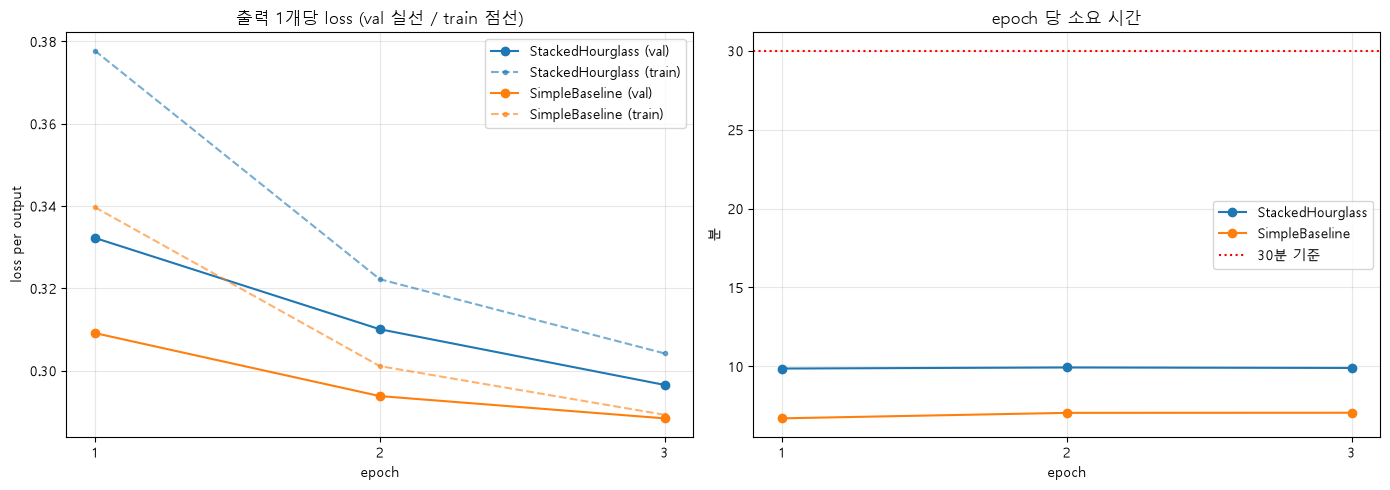

모델                      최종 val/출력      최저 val/출력    평균 epoch(분)
StackedHourglass           0.2965         0.2965            9.9
SimpleBaseline             0.2884         0.2884            6.9


In [36]:
def load_history(tag):
    """학습 중 저장해 둔 history JSON 을 읽는다."""
    path = os.path.join(MODEL_PATH, f'{tag}-history.json')
    with open(path, encoding='utf-8') as f:
        return json.load(f)


def get_history(tag, result=None):
    """메모리에 결과가 있으면 그것을, 없으면 저장된 JSON 을 쓴다."""
    if result is not None:
        return result['history']
    return load_history(tag)


histories = {
    'StackedHourglass': get_history('hourglass', globals().get('hourglass_result')),
    'SimpleBaseline': get_history('simplebaseline', globals().get('simplebaseline_result')),
}

all_epochs = sorted({h['epoch'] for hist in histories.values() for h in hist})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'StackedHourglass': 'tab:blue', 'SimpleBaseline': 'tab:orange'}

for name, history in histories.items():
    epochs = [h['epoch'] for h in history]
    val = [h['val_loss_per_output'] for h in history]
    train = [h['train_loss_per_output'] for h in history]

    axes[0].plot(epochs, val, marker='o', color=colors[name], label=f'{name} (val)')
    axes[0].plot(epochs, train, marker='.', linestyle='--', alpha=0.6,
                 color=colors[name], label=f'{name} (train)')
    axes[1].plot(epochs, [h['elapsed_min'] for h in history], marker='o',
                 color=colors[name], label=name)

axes[0].set_title('출력 1개당 loss (val 실선 / train 점선)')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss per output')
axes[0].set_xticks(all_epochs)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title('epoch 당 소요 시간')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('분')
axes[1].set_xticks(all_epochs)
axes[1].axhline(30, color='red', linestyle=':', label='30분 기준')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'{"모델":18s} {"최종 val/출력":>14s} {"최저 val/출력":>14s} {"평균 epoch(분)":>14s}')
for name, history in histories.items():
    final = history[-1]['val_loss_per_output']
    best = min(h['val_loss_per_output'] for h in history)
    mean_min = sum(h['elapsed_min'] for h in history) / len(history)
    print(f'{name:18s} {final:>14.4f} {best:>14.4f} {mean_min:>14.1f}')

---
# 8. 평가

- **정성 평가** : 같은 이미지에 두 모델의 예측을 그려 눈으로 비교
- **정량 평가** : validation 전체에 대해 PCKh@0.5 / PCK@0.2 계산

### heatmap → 좌표

heatmap 의 최대값 위치를 찾으면 되지만, 64×64 heatmap 의 한 칸은 256×256 입력에서 4px 에 해당한다.
이 양자화 오차를 줄이기 위해 **최대점 주변 이웃이 큰 쪽으로 0.25칸 이동**시키는 보정을 넣는다.

In [37]:
import glob

import torch.nn.functional as F


def heatmaps_to_keypoints(heatmaps, refine=True):
    """(B, C, H, W) heatmap 에서 keypoint 좌표를 뽑는다.

    Args:
        heatmaps: (B, C, H, W) 텐서.
        refine: True 면 최대점 주변 이웃을 보고 0.25칸 보정한다.

    Returns:
        coords: (B, C, 2) — 마지막 축은 [x, y] 이며 각각 W, H 로 나눈 0~1 정규화 좌표.
        scores: (B, C) — heatmap 최대값(신뢰도). 0 이면 해당 관절이 비어 있다는 뜻이다.
    """
    batch, channels, height, width = heatmaps.shape
    flat = heatmaps.reshape(batch, channels, height * width)
    scores, indices = flat.max(dim=2)

    y = (indices // width).float()   # 열 개수(width)로 나눈다
    x = (indices % width).float()

    if refine:
        padded = F.pad(heatmaps, (1, 1, 1, 1)).reshape(batch, channels, -1)
        padded_width = width + 2
        row = indices // width + 1
        col = indices % width + 1

        def neighbor(dy, dx):
            """최대점에서 (dy, dx) 만큼 떨어진 이웃 값을 가져온다."""
            offset = (row + dy) * padded_width + (col + dx)
            return padded.gather(2, offset.unsqueeze(-1)).squeeze(-1)

        x = x + torch.sign(neighbor(0, 1) - neighbor(0, -1)) * 0.25
        y = y + torch.sign(neighbor(1, 0) - neighbor(-1, 0)) * 0.25

    coords = torch.stack([x / width, y / height], dim=-1).clamp(0.0, 1.0)
    return coords, scores


def load_trained_model(build_fn, tag=None, checkpoint=None):
    """저장된 체크포인트를 불러와 평가 모드 모델을 만든다."""
    if checkpoint is None:
        candidates = sorted(glob.glob(os.path.join(MODEL_PATH, f'{tag}-epoch-*.pt')),
                            key=os.path.getmtime)
        if not candidates:
            raise FileNotFoundError(f'{tag} 체크포인트를 찾을 수 없다: {MODEL_PATH}')
        checkpoint = candidates[-1]

    model = build_fn().to(DEVICE)
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    model.eval()
    print(f'로드 : {os.path.basename(checkpoint)}')
    return model


@torch.no_grad()
def predict_heatmaps(model, image_tensor):
    """(B, 3, H, W) 입력에 대한 최종 heatmap 을 (B, C, h, w) float32 로 반환한다."""
    model.eval()
    with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16,
                        enabled=DEVICE.type == 'cuda'):
        outputs = model(image_tensor.to(DEVICE))
    return outputs[-1].float().cpu()


def predict_image(model, image, image_shape=IMAGE_SHAPE):
    """임의의 이미지(경로 또는 PIL)를 리사이즈해 예측한다. crop 은 하지 않는다.

    Returns:
        (PIL 이미지, coords (C, 2) 정규화 좌표, scores (C,))
    """
    if isinstance(image, str):
        image = Image.open(image).convert('RGB')

    resized = image.resize((image_shape[1], image_shape[0]))
    array = np.asarray(resized, dtype=np.float32) / 127.5 - 1.0
    tensor = torch.from_numpy(array).permute(2, 0, 1).unsqueeze(0)

    heatmaps = predict_heatmaps(model, tensor)
    coords, scores = heatmaps_to_keypoints(heatmaps)
    return image, coords[0], scores[0]

In [38]:
# 학습이 끝난 두 모델을 불러온다. SimpleBaseline 은 가중치를 덮어쓸 것이므로
# ImageNet 가중치를 다시 받지 않도록 pretrained=False 로 뼈대만 만든다.
eval_hourglass = load_trained_model(build_hourglass, tag='hourglass')
eval_simplebaseline = load_trained_model(
    lambda: SimpleBaseline(IMAGE_SHAPE, num_heatmap=NUM_HEATMAP, pretrained=False),
    tag='simplebaseline')

EVAL_MODELS = {'StackedHourglass': eval_hourglass, 'SimpleBaseline': eval_simplebaseline}

로드 : hourglass-epoch-3-loss-1.1861.pt
로드 : simplebaseline-epoch-3-loss-0.2884.pt


### 8-1. 정성 평가 — validation 샘플

학습 때와 동일하게 ROI 를 crop 한 입력에 대해 예측한다. 맨 왼쪽이 ground truth 이므로
두 모델의 결과를 GT 와 직접 대조할 수 있다.

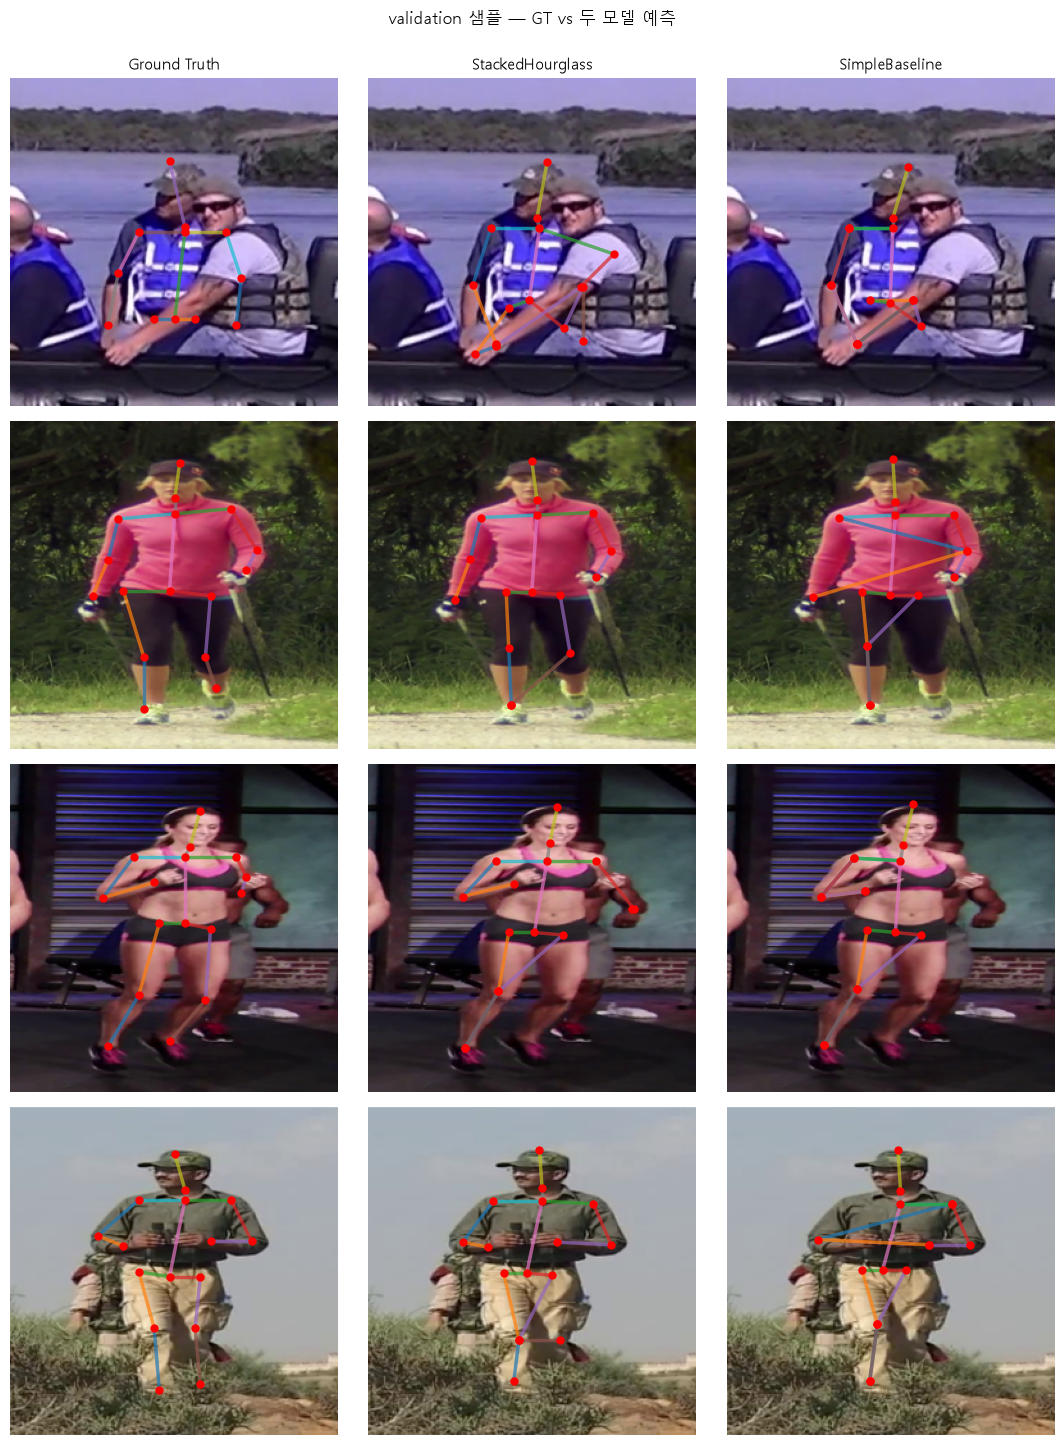

In [39]:
eval_preprocess = Preprocessor(image_shape=IMAGE_SHAPE,
                               heatmap_shape=(*HEATMAP_SIZE, NUM_HEATMAP),
                               is_train=False)

NUM_QUALITATIVE = 4
qualitative_annos = [valid_annotations[i] for i in
                     random.Random(SEED).sample(range(len(valid_annotations)),
                                                NUM_QUALITATIVE)]

fig, axes = plt.subplots(NUM_QUALITATIVE, 3, figsize=(11, 3.6 * NUM_QUALITATIVE))
for row, anno in enumerate(qualitative_annos):
    image = Image.open(anno['filepath']).convert('RGB')
    image_tensor, gt_heatmaps = eval_preprocess(image, anno)
    display_image = tensor_to_image(image_tensor)

    # ground truth : 라벨 heatmap 의 argmax 가 곧 정답 좌표다
    gt_coords, gt_scores = heatmaps_to_keypoints(gt_heatmaps.unsqueeze(0), refine=False)
    draw_pose(axes[row, 0], display_image, gt_coords[0].numpy(),
              visibility=(gt_scores[0] > 0).numpy(), normalized=True)
    axes[row, 0].set_title('Ground Truth' if row == 0 else '', fontsize=11)

    for col, (name, model) in enumerate(EVAL_MODELS.items(), start=1):
        heatmaps = predict_heatmaps(model, image_tensor.unsqueeze(0))
        coords, scores = heatmaps_to_keypoints(heatmaps)
        draw_pose(axes[row, col], display_image, coords[0].numpy(), normalized=True)
        axes[row, col].set_title(name if row == 0 else '', fontsize=11)

plt.suptitle('validation 샘플 — GT vs 두 모델 예측', y=1.0)
plt.tight_layout()
plt.show()

### 8-2. 정성 평가 — 학습에 쓰지 않은 이미지

crop 없이 이미지 전체를 256×256 으로 줄여 넣는다. 학습 분포와 다르기 때문에 성능이 떨어진다.

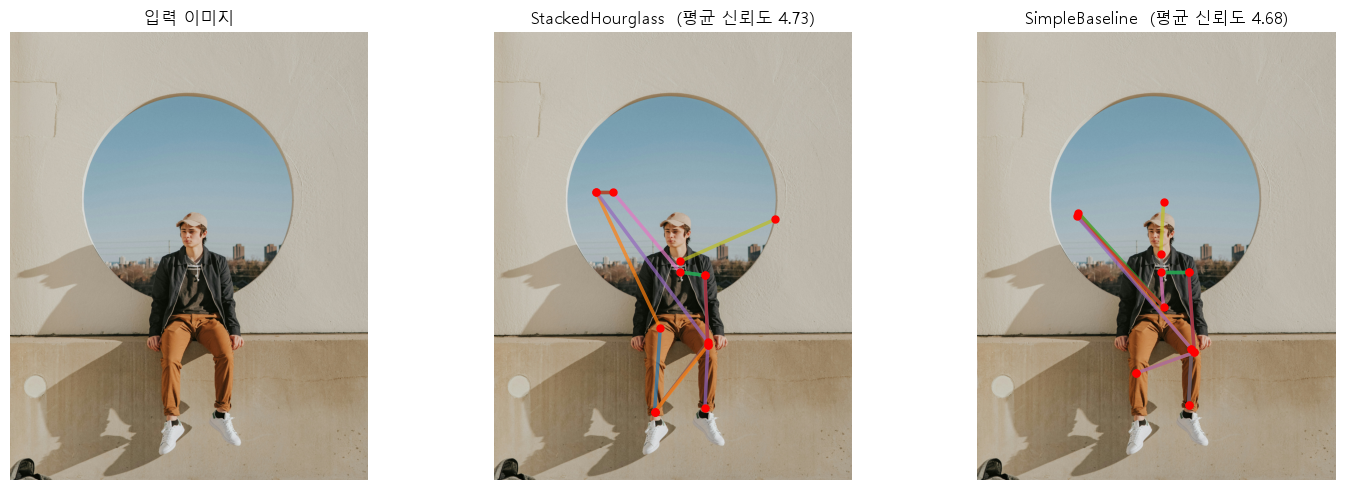

In [41]:
TEST_IMAGE = os.path.join(DATA_PATH, 'test_image.jpg')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(Image.open(TEST_IMAGE).convert('RGB'))
axes[0].set_title('입력 이미지')
axes[0].axis('off')

for ax, (name, model) in zip(axes[1:], EVAL_MODELS.items()):
    image, coords, scores = predict_image(model, TEST_IMAGE)
    draw_pose(ax, image, coords.numpy(), normalized=True)
    ax.set_title(f'{name}  (평균 신뢰도 {scores.mean():.2f})')

plt.tight_layout()
plt.show()

### 8-3. 정량 평가 — PCKh@0.5 / PCK@0.2

**PCK(Percentage of Correct Keypoints)** 는 예측이 정답에서 일정 거리 안에 들어온 관절의 비율이다.
기준 거리를 무엇으로 정규화하느냐에 따라 이름이 갈린다.

| 지표 | 기준 거리 | 의미 |
|---|---|---|
| PCKh@0.5 | 머리 크기 × 0.5 | 사람 크기에 비례 — MPII 표준 지표 |
| PCK@0.2 | crop 영역 한 변 × 0.2 | 사람 영역 대비 상대 거리 |

**구현 한계**

- MPII 공식 PCKh 는 `.mat` 파일의 **head bounding box** 로 머리 크기를 정한다.
  제공된 json 에는 그 정보가 없어, 여기서는 **`head_top`(9) 과 `upper_neck`(8) 사이 거리**로 근사했다.
  따라서 아래 수치는 논문에 실린 PCKh 값과 직접 비교할 수 없다. 두 모델을 같은 잣대로 비교하는 용도다.
- 라벨 heatmap 이 비어 있는 관절(가려졌거나 crop 밖)은 평가에서 제외한다.

In [42]:
@torch.no_grad()
def evaluate_pck(model, loader, pckh_alpha=0.5, pck_alpha=0.2):
    """validation 데이터로 PCKh@0.5 와 PCK@0.2 를 계산한다.

    Args:
        model: 평가할 모델.
        loader: (image, heatmap) 을 돌려주는 DataLoader.
        pckh_alpha: 머리 크기에 곱할 비율(0.5 = PCKh@0.5).
        pck_alpha: crop 한 변에 곱할 비율(0.2 = PCK@0.2).

    Returns:
        dict: pckh / pck / per_joint_pckh(16,) / 평가에 쓰인 관절 수.
    """
    joint_correct = torch.zeros(NUM_JOINTS)
    joint_total = torch.zeros(NUM_JOINTS)
    pck_correct = torch.zeros(NUM_JOINTS)
    pck_total = torch.zeros(NUM_JOINTS)

    for images, labels in tqdm(loader, desc='PCK 평가', leave=False):
        pred_heatmaps = predict_heatmaps(model, images)
        pred_coords, _ = heatmaps_to_keypoints(pred_heatmaps)
        gt_coords, gt_scores = heatmaps_to_keypoints(labels, refine=False)

        valid = gt_scores > 0                                   # (B, C)
        distance = torch.norm(pred_coords - gt_coords, dim=2)   # (B, C) 정규화 좌표 기준

        # --- PCK@0.2 : crop 한 변을 기준으로 정규화된 거리 ---
        pck_correct += ((distance < pck_alpha) & valid).float().sum(dim=0)
        pck_total += valid.float().sum(dim=0)

        # --- PCKh@0.5 : head_top(9) - upper_neck(8) 거리로 머리 크기를 근사 ---
        head_size = torch.norm(gt_coords[:, HEAD_TOP] - gt_coords[:, UPPER_NECK], dim=1)
        has_head = valid[:, HEAD_TOP] & valid[:, UPPER_NECK] & (head_size > 1e-6)

        threshold = (pckh_alpha * head_size).unsqueeze(1)       # (B, 1)
        usable = valid & has_head.unsqueeze(1)
        joint_correct += ((distance < threshold) & usable).float().sum(dim=0)
        joint_total += usable.float().sum(dim=0)

    per_joint = joint_correct / joint_total.clamp(min=1)
    return {
        'pckh': (joint_correct.sum() / joint_total.sum().clamp(min=1)).item(),
        'pck': (pck_correct.sum() / pck_total.sum().clamp(min=1)).item(),
        'per_joint_pckh': per_joint,
        'evaluated_joints': int(joint_total.sum().item()),
    }

In [43]:
EVAL_SUBSET_SIZE = None

eval_loader = create_dataloader(valid_annotations, batch_size=BATCH_SIZE, is_train=False,
                                num_workers=NUM_WORKERS, subset_size=EVAL_SUBSET_SIZE)

pck_results = {}
for name, model in EVAL_MODELS.items():
    pck_results[name] = evaluate_pck(model, eval_loader)
    result = pck_results[name]
    print(f'{name:18s} PCKh@0.5 {result["pckh"]:.4f} | PCK@0.2 {result["pck"]:.4f} '
          f'| 평가 관절 {result["evaluated_joints"]:,}개')

PCK 평가:   0%|          | 0/185 [00:00<?, ?it/s]

StackedHourglass   PCKh@0.5 0.6642 | PCK@0.2 0.8172 | 평가 관절 43,970개


PCK 평가:   0%|          | 0/185 [00:00<?, ?it/s]

SimpleBaseline     PCKh@0.5 0.6122 | PCK@0.2 0.7661 | 평가 관절 43,970개


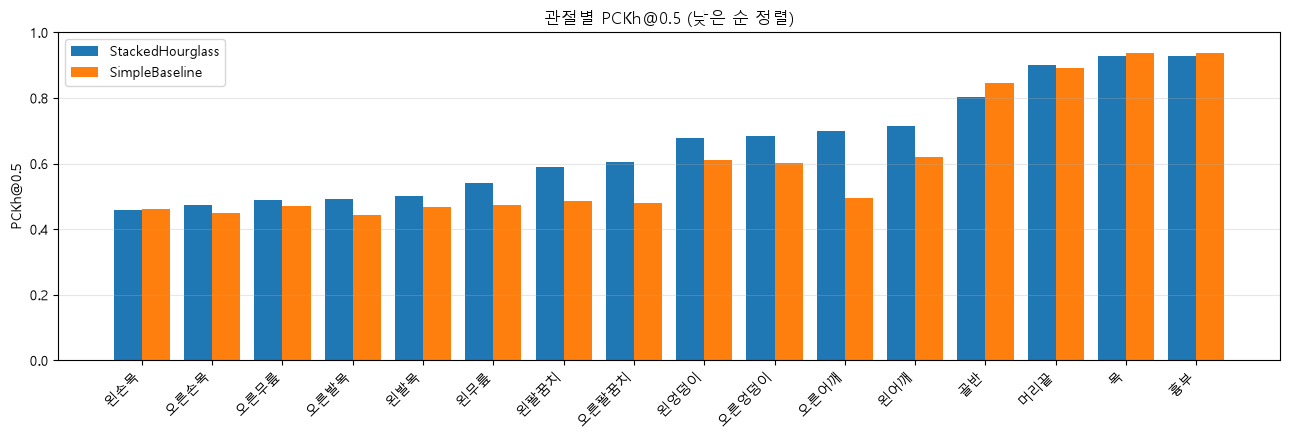

관절            Hourglass   SimpleBaseline       차이
왼손목               0.459            0.462   +0.003
오른손목              0.474            0.451   -0.024
오른무릎              0.490            0.469   -0.021
오른발목              0.491            0.442   -0.049
왼발목               0.501            0.467   -0.034
왼무릎               0.541            0.474   -0.067
왼팔꿈치              0.589            0.484   -0.104
오른팔꿈치             0.604            0.479   -0.125
왼엉덩이              0.677            0.610   -0.067
오른엉덩이             0.683            0.600   -0.083
오른어깨              0.700            0.495   -0.205
왼어깨               0.713            0.620   -0.093
골반                0.802            0.845   +0.043
머리끝               0.902            0.892   -0.010
목                 0.928            0.936   +0.008
흉부                0.929            0.935   +0.007


In [44]:
# 관절별 PCKh 비교
order = torch.argsort(pck_results['StackedHourglass']['per_joint_pckh'])
positions = np.arange(NUM_JOINTS)

fig, ax = plt.subplots(figsize=(13, 4.5))
for offset, (name, color) in zip((-0.2, 0.2),
                                 [('StackedHourglass', 'tab:blue'),
                                  ('SimpleBaseline', 'tab:orange')]):
    values = pck_results[name]['per_joint_pckh'][order].numpy()
    ax.bar(positions + offset, values, width=0.4, label=name, color=color)

ax.set_xticks(positions)
ax.set_xticklabels([JOINT_NAMES_KO[i] for i in order], rotation=45, ha='right')
ax.set_ylabel('PCKh@0.5')
ax.set_title('관절별 PCKh@0.5 (낮은 순 정렬)')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f'{"관절":10s} {"Hourglass":>12s} {"SimpleBaseline":>16s} {"차이":>8s}')
for i in order.tolist():
    hourglass_value = pck_results['StackedHourglass']['per_joint_pckh'][i].item()
    simple_value = pck_results['SimpleBaseline']['per_joint_pckh'][i].item()
    print(f'{JOINT_NAMES_KO[i]:10s} {hourglass_value:>12.3f} {simple_value:>16.3f} '
          f'{simple_value - hourglass_value:>+8.3f}')

---
# 9. 비교 분석

## 9-1. 실험 조건

| 구분 | 항목 | 값 |
|---|---|---|
| **동일** | 데이터 | train 22,246 / valid 2,958 (전체, 서브셋 축소 없음) |
| | 전처리 | 동일 `Preprocessor` (ROI crop, margin 0.1~0.3 랜덤, 256×256, heatmap 64×64) |
| | epochs / batch / lr | 3 / 16 / 7e-4 (Adam, warmup 500 step) |
| | loss | weighted MSE (keypoint 위치 82배 가중) |
| | seed | 42 (데이터 순서·초기화 고정) |
| **차이** | 구조 | 4-stage vs 1-stage |
| | 사전학습 | 없음 vs ImageNet ResNet50 |
| | BN momentum | 0.9 (실습 원본) vs 0.1 (공식 구현) |

## 9-2. 학습 진행

| 항목 | StackedHourglass | SimpleBaseline |
|---|---|---|
| epoch 1 val / 출력 | 0.3322 | **0.3091** |
| epoch 2 val / 출력 | 0.3101 | **0.2938** |
| epoch 3 val / 출력 | 0.2965 | **0.2884** |
| epoch 2→3 감소폭 | **-0.0136** | -0.0054 |
| 최종 train / 출력 | 0.3042 | 0.2893 |

**loss 만 보면 SimpleBaseline 이 전 구간에서 앞선다.** ImageNet 사전학습 backbone의 효과로 보인다.

다만 **감소 추세는 반대**다. epoch 2→3 구간에서 Hourglass 는 -0.0136, SimpleBaseline 은 -0.0054 로 Hourglass 쪽 기울기가 2.5배 가파르다. SimpleBaseline 은 3 epoch 만에 개선폭이 눈에 띄게 감소됐다. 3 epoch 시점의 최종 격차는 0.0081(2.7%)에 불과하므로, **더 학습하면 순서가 바뀔 여지가 있다.**

두 모델 모두 train loss 와 val loss 가 거의 같거나 val 이 더 낮다 (Hourglass train 0.3042 / val 0.2965). 과적합 구간에 들어가지 않았고, underfitting인 상태다.
train 쪽에만 랜덤 margin 증강이 걸려 있는 것도 val 이 더 낮게 나온 이유다.

## 9-3. 정확도

| 지표 | StackedHourglass | SimpleBaseline | 차이 |
|---|---|---|---|
| PCKh@0.5 | **0.6642** | 0.6122 | +0.0520 |
| PCK@0.2 | **0.8172** | 0.7661 | +0.0511 |

validation 2,958 샘플의 **43,970개 관절**(전체 47,328개 중 92.9%, 나머지는 가려졌거나 crop 밖)로 평가했다.

**loss 와 정확도의 순위가 뒤집혔다.** SimpleBaseline 이 loss 는 2.7% 낮은데 PCKh 는 5.2%p(상대 8.5%) 낮다. 두 지표가 서로 다른 것을 재기 때문이다.

- weighted MSE 는 heatmap **전체 픽셀의 평균 오차**다. 대략 맞는 위치에 완만한 봉우리를 그려도 낮게 나온다.
- PCKh 는 봉우리의 **argmax 위치**만 본다. 2~3px 만 어긋나도 임계값을 넘으면 오답으로 센다.

이 시점에서는 SimpleBaseline 이 "대체로 맞지만 덜 뾰족한" 예측을 내놓았기 때문이라고 가정했다. 9-6 에서 직접 측정한 결과 **봉우리 높이는 두 모델이 사실상 같았고(5.22 vs 5.16), 위치 오차만 SimpleBaseline 이 20.6% 컸다.**

### 관절군별 PCKh@0.5

| 관절군 | Hourglass | SimpleBaseline | 차이 |
|---|---|---|---|
| 머리·몸통 (머리끝/목/흉부/골반) | 0.890 | **0.902** | **+0.012** |
| 어깨 | **0.706** | 0.558 | -0.149 |
| 팔꿈치 | **0.597** | 0.482 | -0.115 |
| 엉덩이 | **0.680** | 0.605 | -0.075 |
| 무릎 | **0.516** | 0.471 | -0.044 |
| 발목 | **0.496** | 0.455 | -0.041 |
| 손목 | **0.467** | 0.457 | -0.010 |

**격차는 어깨·팔꿈치에 몰려 있다.** 개별 관절 최대 격차는 오른어깨 -0.205 였다. 반대로 머리·몸통에서는 SimpleBaseline 이 오히려 근소하게 앞선다(골반 +0.043, 목 +0.008, 흉부 +0.007).

SimpleBaseline 은 encoder 가 8×8 까지 줄인 뒤 **skip connection 없이** deconv 3단만으로 64×64 를 복원한다. 몸통처럼 크고 위치가 안정적인 부위는 저해상도 feature 만으로도 충분하지만, 팔처럼 자세에 따라 위치가 크게 변하는 부위는 소실된 고해상도 정보가 필요하다.
Hourglass 는 각 해상도의 feature 를 skip connection 으로 직접 더해주고, 스택마다 heatmap 을 보정한다.

한편 손목은 두 모델 모두 0.46 수준으로 최하위이고 격차도 거의 없다(-0.010). **어느 구조로도 아직 못 푸는 난이도**라는 뜻으로, 3 epoch의 한계로 보인다.

### EDA 예측과 대조

2-6 에서 *"가시성이 가장 낮은 발목(0.70)·무릎(0.83) 의 성능이 가장 낮을 것"* 이라고 예상했다.

- 맞은 부분 : 발목(0.496/0.455)·무릎(0.516/0.472)은 실제로 하위권이었다.
- 틀린 부분 : **최하위는 손목(0.467/0.457)** 이었다. 손목은 가시성 하위 5위 안에 들지 않았다. 반대로 가시성 0.972 인 골반은 PCKh 0.802/0.845 로 중상위에 그쳤다.

가시성은 난이도의 일부일 뿐이고, **부위의 크기와 움직임 자유도**가 더 크게 작용한 것으로 보인다.
손목은 가려지지 않아도 위치 변화가 크고 면적이 작아 heatmap peak 를 정확히 맞히기 어렵다.

## 9-4. 학습 효율

| 항목 | StackedHourglass | SimpleBaseline | 비고 |
|---|---|---|---|
| 파라미터 | 16.3M | **34.0M** | SimpleBaseline 이 2.09배 |
| epoch 당 시간 | 9.9분 | **6.9분** | 30% 단축 |
| 총 학습 시간(3 epoch) | 29.7분 | **20.9분** | 8.8분 단축 |
| peak VRAM | 4.0GB | **1.5GB** | 62% 절감 |

**파라미터가 2배 많은 쪽이 더 빠르고 메모리도 덜 쓴다.** 파라미터 수가 아니라 **중간 활성값(activation)의 크기**가 자원 사용을 지배하기 때문이다.
Hourglass 는 64×64×256 feature 를 4개 스택 내내 유지하며 각 스택 안에서 다시 4단계로 오르내린다.
SimpleBaseline 은 8×8 까지 줄인 뒤 한 번만 올라온다. ResNet50 의 25M 파라미터는 대부분 저해상도 구간에 있다.

## 9-5. 루브릭 1 — 1 epoch 30분 이내

| 실행 | 1 epoch 소요 |
|---|---|
| probe (첫 실행) | 14.3분 |
| 본 학습 Hourglass | 9.9분 |
| 본 학습 SimpleBaseline | 6.9분 |

**전체 22,246 샘플을 서브셋 축소 없이 사용**하고도 모든 실행이 30분 기준을 통과했다.

## 9-6. 가설 검증 — "덜 뾰족한 예측" 이 맞는가

9-3 에서 *"SimpleBaseline 은 loss 는 낮지만 heatmap peak 가 덜 뾰족해 argmax 위치가 부정확할 것"* 이라는 가설을 세웠다.

- **peak 값** : 예측 heatmap 의 채널별 최대값. 정답 heatmap 의 peak 는 12 이므로, 이 값이 작을수록 봉우리가 낮고 완만하다.
- **위치 오차** : 예측 좌표와 정답 좌표의 거리(crop 한 변 = 1.0 기준).

가설이 맞다면 SimpleBaseline 은 **peak 값이 더 낮고 위치 오차는 더 큰** 결과가 나와야 한다.

In [46]:
@torch.no_grad()
def diagnose_heatmaps(model, loader, max_batches=60):
    """예측 heatmap 의 peak 값과 위치 오차를 측정한다.

    'loss 는 낮은데 PCK 는 낮다' 는 현상이 봉우리 모양 때문인지 확인하기 위한 진단 함수다.

    Returns:
        dict: peak 평균/중앙값, 위치 오차 평균/중앙값(정규화 좌표 기준).
    """
    peaks, distances = [], []

    for count, (images, labels) in enumerate(tqdm(loader, desc='heatmap 진단', leave=False)):
        if count >= max_batches:
            break
        pred_heatmaps = predict_heatmaps(model, images)
        pred_coords, pred_scores = heatmaps_to_keypoints(pred_heatmaps)
        gt_coords, gt_scores = heatmaps_to_keypoints(labels, refine=False)

        valid = gt_scores > 0   # 라벨이 있는 관절만
        peaks.append(pred_scores[valid])
        distances.append(torch.norm(pred_coords - gt_coords, dim=2)[valid])

    peaks = torch.cat(peaks)
    distances = torch.cat(distances)
    return {
        'peak_mean': peaks.mean().item(),
        'peak_median': peaks.median().item(),
        'dist_mean': distances.mean().item(),
        'dist_median': distances.median().item(),
        'joints': peaks.numel(),
    }


diagnosis = {name: diagnose_heatmaps(model, eval_loader)
             for name, model in EVAL_MODELS.items()}

print(f'{"모델":18s} {"peak 평균":>10s} {"peak 중앙":>10s} {"오차 평균":>10s} {"오차 중앙":>10s}')
for name, values in diagnosis.items():
    print(f'{name:18s} {values["peak_mean"]:>10.2f} {values["peak_median"]:>10.2f} '
          f'{values["dist_mean"]:>10.4f} {values["dist_median"]:>10.4f}')
print(f'\n(정답 heatmap 의 peak 값은 12.0, 거리는 crop 한 변을 1.0 으로 정규화한 값)')
print(f'평가 관절 수 : {diagnosis["StackedHourglass"]["joints"]:,}')

heatmap 진단:   0%|          | 0/185 [00:00<?, ?it/s]

heatmap 진단:   0%|          | 0/185 [00:00<?, ?it/s]

모델                    peak 평균    peak 중앙      오차 평균      오차 중앙
StackedHourglass         5.22       5.19     0.0997     0.0371
SimpleBaseline           5.16       5.12     0.1202     0.0445

(정답 heatmap 의 peak 값은 12.0, 거리는 crop 한 변을 1.0 으로 정규화한 값)
평가 관절 수 : 14,331


**측정 결과** (validation 14,331개 관절 / 정답 peak = 12.0 / 거리는 crop 한 변 = 1.0)

| 모델 | peak 평균 | peak 중앙 | 오차 평균 | 오차 중앙 |
|---|---|---|---|---|
| StackedHourglass | 5.22 | 5.19 | **0.0997** | **0.0371** |
| SimpleBaseline | 5.16 | 5.12 | 0.1202 | 0.0445 |

- **peak 값 비교** : 5.22 대 5.16 으로 차이가 1.2% 에 불과하다. 봉우리 높이만 놓고 보면 두 모델은 사실상 같다. 다만 **둘 다 정답 peak(12.0)의 43% 수준**에 머물러 있다. 3 epoch 으로는 봉우리를 충분히 세우지 못했다는 의미이다.
- **위치 오차 비교** : 평균 0.0997 대 0.1202 로 SimpleBaseline 이 **20.6% 크고**, 중앙값도 0.0371 대 0.0445 로 19.9% 크다. PCKh 격차(-5.2%p)와 방향이 일치한다. 한편 두 모델 모두 **평균이 중앙값의 2.7배**다. 대부분의 관절은 꽤 정확한데(중앙값 0.037 = 256px 기준 약 9px), 완전히 빗나간 소수의 관절이 평균을 끌어올리고 있다.
- **가설이 맞았는가** :
    - 기각 : "SimpleBaseline 의 봉우리가 덜 뾰족하다" 는 근거가 없다. peak 차이 1.2% 는 무시할 수준이다.
    - 확인 : "위치 오차가 더 크다" 는 맞았다. 20% 차이가 그대로 PCKh 격차로 이어졌다.

## 9-7. 결론

**3 epoch·동일 하이퍼파라미터라는 조건에서는 StackedHourglass 가 더 정확했다.**
PCKh@0.5 기준 0.6642 대 0.6122 로 5.2%p 앞섰고, 격차는 어깨·팔꿈치 같은 사지 관절에 몰려 있었다.
skip connection 과 스택별 중간 supervision 이 정밀한 위치 추정에 유리하게 작용한 것으로 보인다.

**반면 SimpleBaseline 은 효율에서 앞섰다.** epoch 당 30% 빠르고 VRAM 은 62% 적게 쓰면서 loss 는 오히려 더 낮았고, 사전학습 backbone 덕에 1 epoch 만에 Hourglass 의 2 epoch 수준에 도달했다.


원 논문에서 SimpleBaseline 은 Hourglass 를 앞선다. 이번 결과가 그와 반대인 것을 두고 StackedHourglass가 SimpleBaseline보다 성능이 좋다고 결론내릴 수 없다. 다음 조건들이 결과를 좌우할 수 있기 때문이다.

1. **학습량** : 논문은 140 epoch 기준이다. 여기서는 3 epoch 이고, 두 모델 모두 아직 underfit 상태다.
   9-2 에서 본 감소 기울기(Hourglass 가 2.5배 가파름)를 보면 더 학습했을 때의 순서는 예측할 수 없다.
2. **learning rate** : 모델별 튜닝을 하지 않았다. 사전학습 backbone 을 쓰는 SimpleBaseline 은
   더 낮은 lr 이나 backbone 차등 lr 에서 유리할 수 있다.
3. **평가 지표** : head bounding box 가 없어 PCKh 를 근사했다.

---
# 10. 회고

## 배운 점

- **파라미터 수는 자원 사용량의 지표가 아니다.** 파라미터가 2.09배 많은 SimpleBaseline이 VRAM 은 62% 적게 쓰고 30% 빨랐다. 해상도를 얼마나 오래 유지하느냐가 실제 비용을 결정한다.
- **비교 실험은 조건을 맞추는 일이 대부분이다.** loss 스케일(스택 4개 vs 1개), 데이터 순서(seed), 서브셋, lr 을 맞추는 데 대부분의 설계가 들어갔고, 그 중 하나만 어긋나도 결론이 흔들린다.


## 아쉬운 점

- **3 epoch 은 결론을 내기에 부족하다.** 두 모델 모두 underfit 이고 loss 가 계속 떨어지는 중이었다. 9-2 의 기울기 차이를 보면 더 학습했을 때 순위가 뒤집힐 가능성이 있다.
- **lr 을 모델별로 탐색하지 못했다.** 동일 조건 비교라는 원칙 때문이었지만, SimpleBaseline 이 불리한 lr 을 사용하여 성능이 더 떨어졌을 가능성이 있다.
- **`num_workers = 0` 제약.** 파이프라인을 노트북 안에 두면서 Windows 의 spawn 워커를 쓸 수 없게 됐다.